# Clasificación de Tweets del Huracán María

## Cargar el Dataset HumAID_maria_tweets

In [160]:
import pandas as pd

# URL directa al archivo CSV en GitHub
url = 'https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_maria_tweets/HumAID_maria_tweets.csv'

# Cargar el dataset
df = pd.read_csv(url)

# Mostrar las primeras filas del dataset
df.head()

,tweet_id,tweet_text,class_label,split
0,914134332226330625,San Juan: Trump lashes out with good reason. #...,other_relevant_information,train
1,910783670134476800,Hurricane Maria Live Updates: Catastrophic Flo...,caution_and_advice,train
2,912134938727780355,"Getting food to the island is, obviously, crit...",rescue_volunteering_or_donation_effort,train
3,910669838842056704,My heart breaks for the families in Puerto Ric...,sympathy_and_support,train
4,912287091026997248,"#B-FAST sending medical, reconstruction &amp; ...",rescue_volunteering_or_donation_effort,train


Información general del Dataset

In [161]:
# Información del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7278 entries, 0 to 7277
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   tweet_id     7278 non-null   int64 
 1   tweet_text   7278 non-null   object
 2   class_label  7278 non-null   object
 3   split        7278 non-null   object
dtypes: int64(1), object(3)
memory usage: 227.6+ KB


Número de columnas y sus nombres

In [162]:
# Número de columnas y nombres
print("Número de columnas:", df.shape[1])
print("\nNombres de las columnas:")
print(df.columns.tolist())

Número de columnas: 4

Nombres de las columnas:
['tweet_id', 'tweet_text', 'class_label', 'split']


Tamaño total del Dataset

In [163]:
# Tamaño (filas, columnas)
print("Tamaño del dataset:", df.shape)

Tamaño del dataset: (7278, 4)


Recuento de valores únicos por columna

In [164]:
# Valores únicos por columna
for col in df.columns:
    print(f"\nColumna: {col}")
    print(df[col].nunique(), "valores únicos")



Columna: tweet_id
7278 valores únicos

Columna: tweet_text
7278 valores únicos

Columna: class_label
9 valores únicos

Columna: split
3 valores únicos


División de los datos: train, val, test

In [165]:
# Recuento de tweets por división (split)
print("Distribución por split:")
print(df['split'].value_counts())

Distribución por split:
split
train    5094
test     1442
dev       742
Name: count, dtype: int64


 Categorías (class_label) y su distribución

In [166]:
# Recuento por clase
print("Distribución de clases:")
print(df['class_label'].value_counts())

Distribución de clases:
class_label
rescue_volunteering_or_donation_effort    1977
other_relevant_information                1568
infrastructure_and_utility_damage         1427
requests_or_urgent_needs                   711
sympathy_and_support                       672
injured_or_dead_people                     302
not_humanitarian                           270
caution_and_advice                         220
displaced_people_and_evacuations           131
Name: count, dtype: int64


Verificar si hay valores nulos

In [167]:
# Verificación de valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
tweet_id       0
tweet_text     0
class_label    0
split          0
dtype: int64


Gráfico de distribución de clases

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\134149315.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='class_label', order=df['class_label'].value_counts().index, palette='viridis')


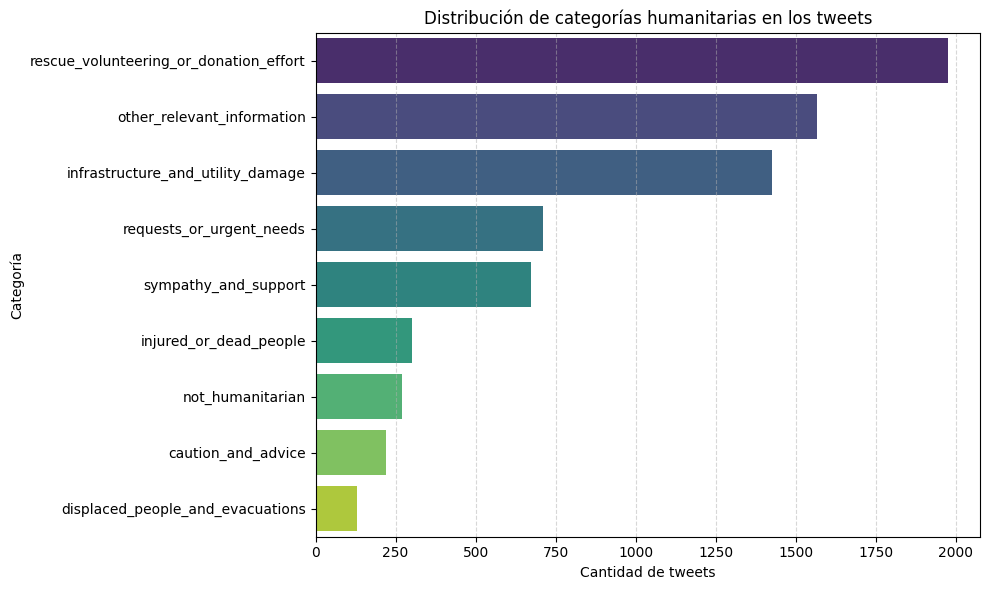

In [168]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='class_label', order=df['class_label'].value_counts().index, palette='viridis')
plt.title('Distribución de categorías humanitarias en los tweets')
plt.xlabel('Cantidad de tweets')
plt.ylabel('Categoría')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Gráfico de la distribución por el conjunto "split"

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\1294282084.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='split', order=df['split'].value_counts().index, palette='pastel')


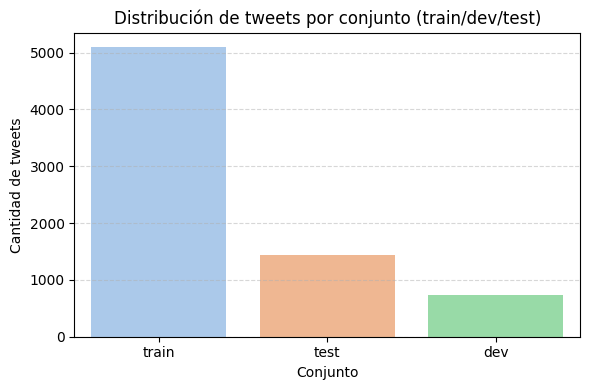

In [169]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='split', order=df['split'].value_counts().index, palette='pastel')
plt.title('Distribución de tweets por conjunto (train/dev/test)')
plt.xlabel('Conjunto')
plt.ylabel('Cantidad de tweets')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Gráfico de tweets por clase desglosado por conjunto (split)

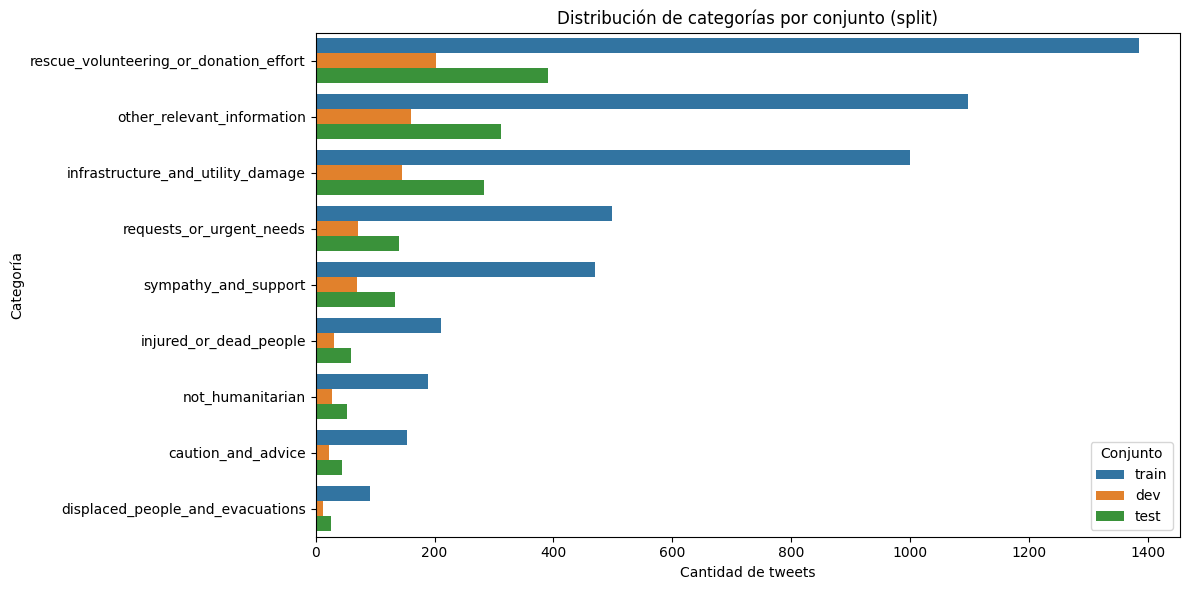

In [170]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='class_label', hue='split', order=df['class_label'].value_counts().index)
plt.title('Distribución de categorías por conjunto (split)')
plt.xlabel('Cantidad de tweets')
plt.ylabel('Categoría')
plt.legend(title='Conjunto')
plt.tight_layout()
plt.show()

Resumen de frecuencia por clase humanitaria

In [171]:
# Calcular frecuencia absoluta y relativa (porcentaje)
class_summary = df['class_label'].value_counts().reset_index()
class_summary.columns = ['Clase Humanitaria', 'Cantidad de Tweets']
class_summary['Porcentaje (%)'] = 100 * class_summary['Cantidad de Tweets'] / class_summary['Cantidad de Tweets'].sum()

# Redondear los porcentajes a dos decimales
class_summary['Porcentaje (%)'] = class_summary['Porcentaje (%)'].round(2)

# Mostrar la tabla
class_summary

,Clase Humanitaria,Cantidad de Tweets,Porcentaje (%)
0,rescue_volunteering_or_donation_effort,1977,27.16
1,other_relevant_information,1568,21.54
2,infrastructure_and_utility_damage,1427,19.61
3,requests_or_urgent_needs,711,9.77
4,sympathy_and_support,672,9.23
5,injured_or_dead_people,302,4.15
6,not_humanitarian,270,3.71
7,caution_and_advice,220,3.02
8,displaced_people_and_evacuations,131,1.80


## Preprocesamiento del Dataset

Reclasificación

In [172]:
# Diccionario de mapeo de clases a etiquetas generales
label_map = {
    'other_relevant_information': 'informative',
    'caution_and_advice': 'informative',
    'rescue_volunteering_or_donation_effort': 'informative',
    'infrastructure_and_utility_damage': 'informative',
    'displaced_people_and_evacuations': 'informative',
    'requests_or_urgent_needs': 'informative',
    'injured_or_dead_people': 'informative',
    'sympathy_and_support': 'neutral',
    'not_humanitarian': 'not_informative'
}

# Aplicar el mapeo con manejo de errores
df['info_label'] = df['class_label'].map(label_map)

# Verificar si alguna etiqueta no fue mapeada correctamente
unmapped = df[df['info_label'].isnull()]
if not unmapped.empty:
    print("Advertencia: hay clases no mapeadas:")
    print(unmapped['class_label'].unique())

# Recuento final de clases generales
df['info_label'].value_counts()


info_label
informative        6336
neutral             672
not_informative     270
Name: count, dtype: int64

Gráfico de la  la distribución de info_label

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\3060329855.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_plot, x='info_label', order=['informative', 'neutral', 'not_informative'], palette='Set2')


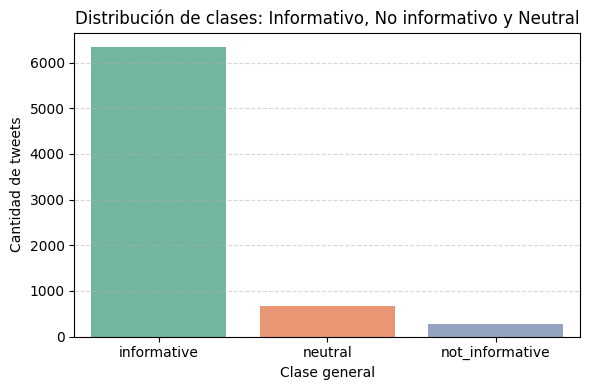

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurarse de que no haya valores nulos
df_plot = df[df['info_label'].notnull()]

# Crear gráfico de barras
plt.figure(figsize=(6, 4))
sns.countplot(data=df_plot, x='info_label', order=['informative', 'neutral', 'not_informative'], palette='Set2')
plt.title('Distribución de clases: Informativo, No informativo y Neutral')
plt.xlabel('Clase general')
plt.ylabel('Cantidad de tweets')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Clean Tweet

In [174]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Descargar recursos necesarios
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Inicializar herramientas
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_tweet(text):
    # 1. Convertir a minúsculas
    text = text.lower()

    # 2. Eliminar caracteres HTML
    text = re.sub(r"&\w+;", " ", text)

    # 3. Eliminar URLs
    text = re.sub(r"http\S+|www.\S+", "", text)

    # 4. Eliminar menciones @usuario
    text = re.sub(r"@\w+", "", text)

    # 5. Eliminar hashtags pero conservar el texto
    text = re.sub(r"#(\w+)", r"\1", text)

    # 6. Eliminar signos de puntuación
    text = text.translate(str.maketrans("", "", string.punctuation))

    # 7. Eliminar números
    text = re.sub(r"\d+", "", text)

    # 8. Tokenizar, eliminar stopwords y lematizar
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    # 9. Unir de nuevo el texto limpio
    return " ".join(words)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Marco\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Marco\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Marco\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Aplicar Clean Tweet al Dataset

In [175]:
# Aplicar a la columna 'tweet_text'
df['clean_text'] = df['tweet_text'].apply(clean_tweet)

# Ver ejemplo de texto limpio
df[['tweet_text', 'clean_text']].sample(5)

,tweet_text,clean_text
1491,RT @SimonStormRider: HUGE difference between t...,rt huge difference tree damage hurricaneirma v...
3534,RT @ThisIsRhiannon: My thoughts go out to thos...,rt thought go puertorico
842,RT @TonyTimmonsWF: .@WellsFargo takes a stand ...,rt take stand help affected hurricanemaria pue...
206,"Maria Knocks Out Power, Triggers Flooding In P...",maria knock power trigger flooding puerto rico
5900,Quick Note on Hurricane Maria &amp; Insured Pu...,quick note hurricane maria insured puerto rico...


Nube de palabras por clase

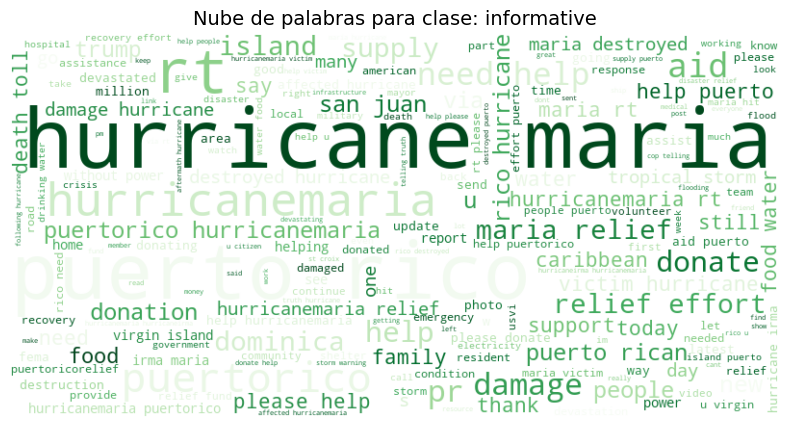

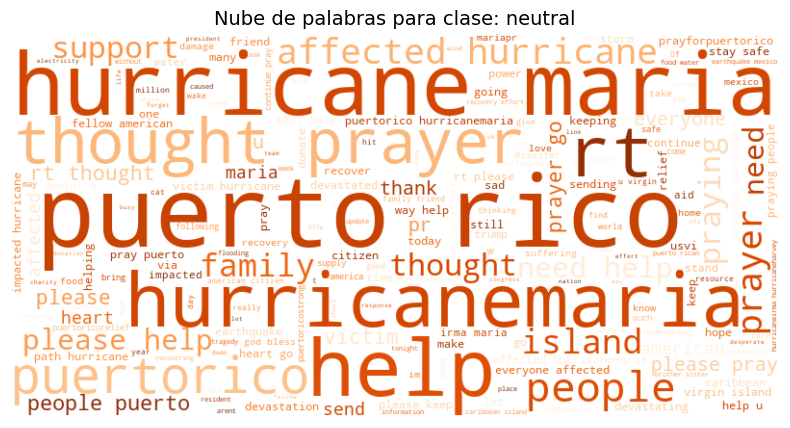

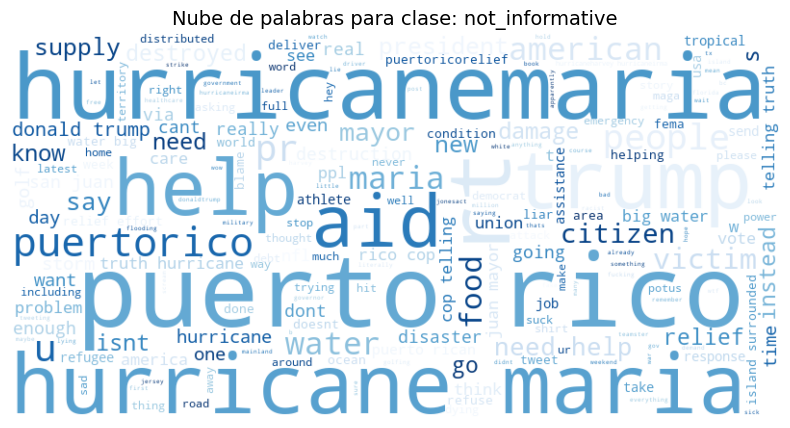

In [176]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Instalar si no lo tienes
# !pip install wordcloud

def generate_wordcloud(label, color='black'):
    text = ' '.join(df[df['info_label'] == label]['clean_text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap=color).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Nube de palabras para clase: {label}', fontsize=14)
    plt.show()

# Generar una para cada clase
generate_wordcloud('informative', color='Greens')
generate_wordcloud('neutral', color='Oranges')
generate_wordcloud('not_informative', color='Blues')

Histograma de longitud e tweets (en palabras)

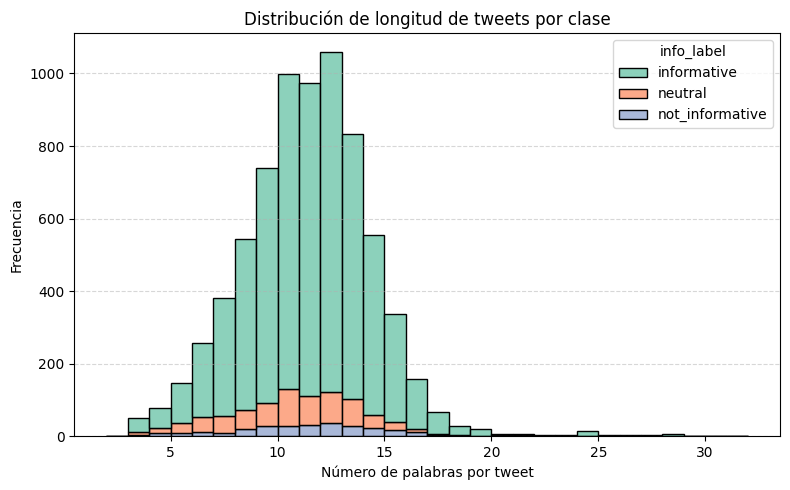

In [177]:
# Crear nueva columna con longitud (en número de palabras)
df['text_length'] = df['clean_text'].apply(lambda x: len(x.split()))

# Histograma de longitud total
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='text_length', hue='info_label', bins=30, multiple='stack', palette='Set2')
plt.title('Distribución de longitud de tweets por clase')
plt.xlabel('Número de palabras por tweet')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Guardar el Dataset procesado como CSV

In [178]:
# Seleccionar solo las columnas que queremos conservar
columns_to_save = ['tweet_id', 'tweet_text', 'clean_text', 'class_label', 'info_label', 'text_length']
df_cleaned = df[columns_to_save]

# Guardar como archivo CSV
df_cleaned.to_csv('HumAID_maria_tweets_cleaned.csv', index=False)

# Mostrar mensaje de confirmación
print("✅ Dataset preprocesado guardado como 'HumAID_maria_tweets_cleaned.csv'")

✅ Dataset preprocesado guardado como 'HumAID_maria_tweets_cleaned.csv'


## Vectorización de los textos

CountVectorizer

In [179]:
from sklearn.feature_extraction.text import CountVectorizer

# Crear el vectorizador con parámetros optimizados
vectorizer = CountVectorizer(
    lowercase=True,             # ya se hizo, pero lo dejamos explícito
    stop_words='english',       # elimina palabras vacías automáticamente
    max_df=0.95,                # ignora palabras que aparecen en >95% de los documentos (muy comunes)
    min_df=5,                   # ignora palabras que aparecen en menos de 5 documentos (muy raras)
    max_features=5000,          # limita el tamaño del vocabulario a las 5000 palabras más frecuentes
)

# Ajustar y transformar
X_bow = vectorizer.fit_transform(df['clean_text'])

# Inspección básica
print("Forma de la matriz Bag of Words:", X_bow.shape)
vocabulario = vectorizer.get_feature_names_out()
print("Primeras 10 palabras del vocabulario:")
print(vocabulario[:10])


Forma de la matriz Bag of Words: (7278, 1689)
Primeras 10 palabras del vocabulario:
['abc' 'able' 'aboard' 'absolutely' 'abt' 'accepted' 'accepting' 'access'
 'accessible' 'according']


## Modelo Naive Bayes

Naive Bayes

In [180]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Filtrar datos válidos (sin valores nulos en texto o etiqueta)
df_valid = df[df['clean_text'].notnull() & df['info_label'].notnull()].copy()

# Paso 1: Reconstruir X e y alineados
X_bow_valid = vectorizer.transform(df_valid['clean_text'])
y_valid = df_valid['info_label'].values
split_valid = df_valid['split'].values

# Paso 2: Separar en train y test
X_train = X_bow_valid[split_valid == 'train']
X_test = X_bow_valid[split_valid == 'test']
y_train = y_valid[split_valid == 'train']
y_test = y_valid[split_valid == 'test']

# Paso 3: Codificar etiquetas
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Paso 4: Entrenar el modelo
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train_enc)

# Paso 5: Predecir y evaluar
y_pred = nb_model.predict(X_test)

print("🔍 Reporte de clasificación:")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

print("📉 Matriz de confusión:")
print(confusion_matrix(y_test_enc, y_pred))


🔍 Reporte de clasificación:
                 precision    recall  f1-score   support

    informative       0.92      0.95      0.93      1256
        neutral       0.66      0.53      0.59       133
not_informative       0.23      0.21      0.22        53

       accuracy                           0.88      1442
      macro avg       0.60      0.56      0.58      1442
   weighted avg       0.87      0.88      0.88      1442

📉 Matriz de confusión:
[[1187   33   36]
 [  61   71    1]
 [  38    4   11]]


Matriz de Confusión

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\2854693322.py:20: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


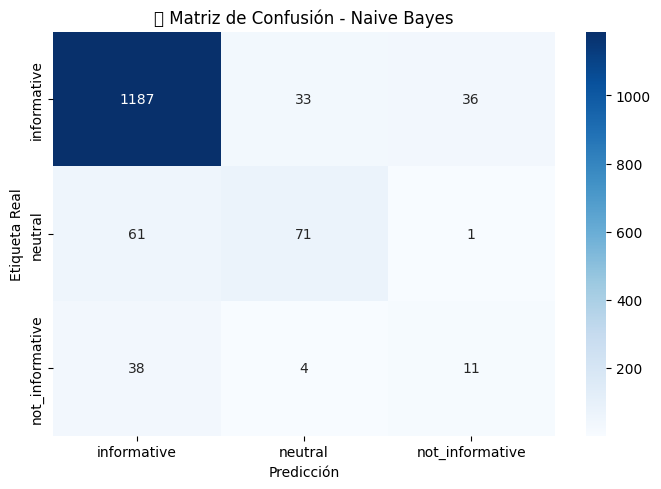

In [181]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Obtener etiquetas reales y predichas
y_test_labels = le.inverse_transform(y_test_enc)
y_pred_labels = le.inverse_transform(y_pred)

# Generar matriz de confusión
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=le.classes_)

# Crear heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)

plt.title("📊 Matriz de Confusión - Naive Bayes")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Real")
plt.tight_layout()
plt.show()

Métricas por clase

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\1871391403.py:31: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


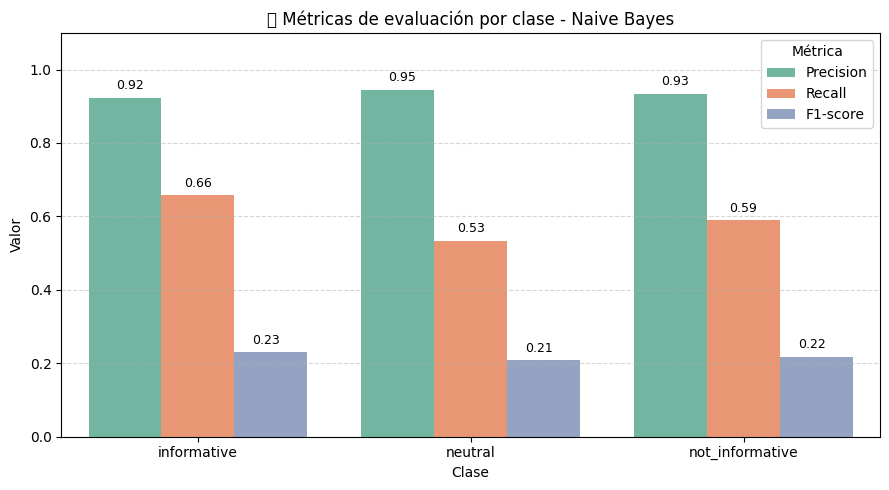

In [182]:
from sklearn.metrics import precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Obtener métricas
precision, recall, f1, _ = precision_recall_fscore_support(y_test_enc, y_pred, zero_division=0)

# Crear dataframe
metrics_df = pd.DataFrame({
    'Clase': np.repeat(le.classes_, 3),
    'Métrica': ['Precision', 'Recall', 'F1-score'] * len(le.classes_),
    'Valor': np.concatenate([precision, recall, f1])
})

# Gráfico de barras agrupadas por clase
plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_df, x='Clase', y='Valor', hue='Métrica', palette='Set2')

# Anotar valores exactos sobre las barras
for i in range(len(metrics_df)):
    row = metrics_df.iloc[i]
    plt.text(i // 3 + (i % 3 - 1) * 0.25, row['Valor'] + 0.015, f"{row['Valor']:.2f}",
             ha='center', va='bottom', fontsize=9)

plt.title("📈 Métricas de evaluación por clase - Naive Bayes")
plt.ylim(0, 1.1)
plt.ylabel("Valor")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Naive Bayes con n-grams(1,2)

In [183]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Filtrar datos válidos
df_valid = df[df['clean_text'].notnull() & df['info_label'].notnull()].copy()

# Vectorización con n-grams (1,2) y limpieza adicional
vectorizer_ngram = CountVectorizer(
    ngram_range=(1, 2),
    stop_words='english',
    max_df=0.95,
    min_df=5,
    max_features=7000  # Puedes ajustar este límite si quieres comparar efectos
)

X_bow_ngrams = vectorizer_ngram.fit_transform(df_valid['clean_text'])
y_valid = df_valid['info_label'].values
split_valid = df_valid['split'].values

# Separar train/test
X_train_ng = X_bow_ngrams[split_valid == 'train']
X_test_ng = X_bow_ngrams[split_valid == 'test']
y_train_ng = y_valid[split_valid == 'train']
y_test_ng = y_valid[split_valid == 'test']

# Codificar etiquetas
le_ng = LabelEncoder()
y_train_enc_ng = le_ng.fit_transform(y_train_ng)
y_test_enc_ng = le_ng.transform(y_test_ng)

# Entrenar modelo
nb_model_ngram = MultinomialNB()
nb_model_ngram.fit(X_train_ng, y_train_enc_ng)

# Predicciones y evaluación
y_pred_ng = nb_model_ngram.predict(X_test_ng)

print("🔍 Reporte de clasificación con n-grams (1,2):")
print(classification_report(y_test_enc_ng, y_pred_ng, target_names=le_ng.classes_))

print("📉 Matriz de confusión:")
print(confusion_matrix(y_test_enc_ng, y_pred_ng))

🔍 Reporte de clasificación con n-grams (1,2):
                 precision    recall  f1-score   support

    informative       0.93      0.93      0.93      1256
        neutral       0.58      0.59      0.59       133
not_informative       0.22      0.19      0.20        53

       accuracy                           0.87      1442
      macro avg       0.58      0.57      0.57      1442
   weighted avg       0.87      0.87      0.87      1442

📉 Matriz de confusión:
[[1167   54   35]
 [  54   79    0]
 [  39    4   10]]


Matriz de confusión

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\1228525479.py:19: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


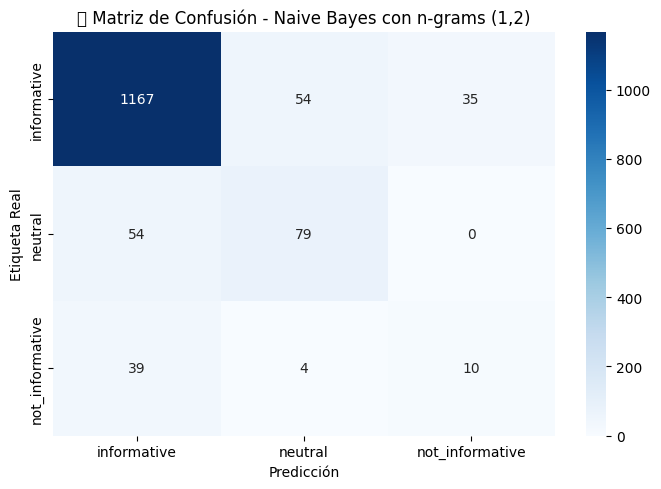

In [184]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Obtener etiquetas reales y predichas
y_test_labels_ng = le_ng.inverse_transform(y_test_enc_ng)
y_pred_labels_ng = le_ng.inverse_transform(y_pred_ng)

# Matriz de confusión
cm_ng = confusion_matrix(y_test_labels_ng, y_pred_labels_ng, labels=le_ng.classes_)

# Visualización tipo heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm_ng, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_ng.classes_, yticklabels=le_ng.classes_)
plt.title("📊 Matriz de Confusión - Naive Bayes con n-grams (1,2)")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Real")
plt.tight_layout()
plt.show()

Métricas por clase

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\3471645036.py:31: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


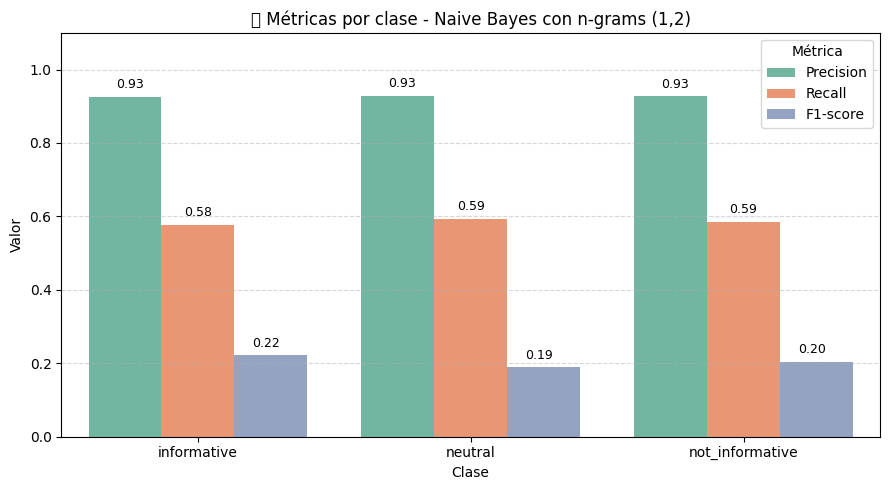

In [185]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np
import pandas as pd

# Calcular métricas por clase
precision_ng, recall_ng, f1_ng, _ = precision_recall_fscore_support(
    y_test_enc_ng, y_pred_ng, zero_division=0
)

# Crear dataframe
metrics_df_ng = pd.DataFrame({
    'Clase': np.repeat(le_ng.classes_, 3),
    'Métrica': ['Precision', 'Recall', 'F1-score'] * len(le_ng.classes_),
    'Valor': np.concatenate([precision_ng, recall_ng, f1_ng])
})

# Gráfico
plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_df_ng, x='Clase', y='Valor', hue='Métrica', palette='Set2')

# Anotar valores sobre las barras
for i in range(len(metrics_df_ng)):
    row = metrics_df_ng.iloc[i]
    plt.text(i // 3 + (i % 3 - 1) * 0.25, row['Valor'] + 0.015, f"{row['Valor']:.2f}",
             ha='center', va='bottom', fontsize=9)

plt.title("📈 Métricas por clase - Naive Bayes con n-grams (1,2)")
plt.ylim(0, 1.1)
plt.ylabel("Valor")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Naive Bayes con TdifVectorizer

In [186]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Filtrar datos válidos
df_valid = df[df['clean_text'].notnull() & df['info_label'].notnull()].copy()

# TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.95,
    min_df=5,
    max_features=7000,
    ngram_range=(1,1)  # Unigramas para comparar justo con BoW
)

X_tfidf = tfidf_vectorizer.fit_transform(df_valid['clean_text'])
y_valid = df_valid['info_label'].values
split_valid = df_valid['split'].values

# Dividir en train/test
X_train_tfidf = X_tfidf[split_valid == 'train']
X_test_tfidf = X_tfidf[split_valid == 'test']
y_train_tfidf = y_valid[split_valid == 'train']
y_test_tfidf = y_valid[split_valid == 'test']

# Codificar etiquetas
le_tfidf = LabelEncoder()
y_train_enc_tfidf = le_tfidf.fit_transform(y_train_tfidf)
y_test_enc_tfidf = le_tfidf.transform(y_test_tfidf)

# Entrenar modelo
nb_model_tfidf = MultinomialNB()
nb_model_tfidf.fit(X_train_tfidf, y_train_enc_tfidf)

# Predecir y evaluar
y_pred_tfidf = nb_model_tfidf.predict(X_test_tfidf)

print("🔍 Reporte de clasificación con TF-IDF:")
print(classification_report(y_test_enc_tfidf, y_pred_tfidf, target_names=le_tfidf.classes_))

print("📉 Matriz de confusión:")
print(confusion_matrix(y_test_enc_tfidf, y_pred_tfidf))

🔍 Reporte de clasificación con TF-IDF:
                 precision    recall  f1-score   support

    informative       0.89      1.00      0.94      1256
        neutral       0.93      0.21      0.34       133
not_informative       0.00      0.00      0.00        53

       accuracy                           0.89      1442
      macro avg       0.61      0.40      0.43      1442
   weighted avg       0.86      0.89      0.85      1442

📉 Matriz de confusión:
[[1254    2    0]
 [ 105   28    0]
 [  53    0    0]]


c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf

Matriz Confusión

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\3410003214.py:19: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


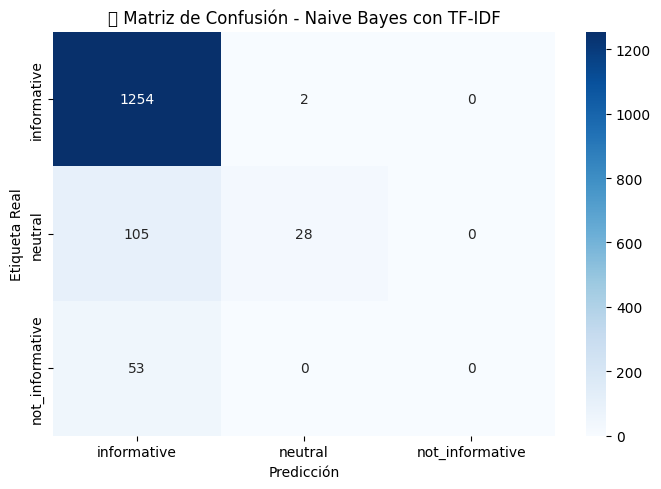

In [187]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Etiquetas reales y predichas (como texto)
y_test_labels_tfidf = le_tfidf.inverse_transform(y_test_enc_tfidf)
y_pred_labels_tfidf = le_tfidf.inverse_transform(y_pred_tfidf)

# Matriz de confusión
cm_tfidf = confusion_matrix(y_test_labels_tfidf, y_pred_labels_tfidf, labels=le_tfidf.classes_)

# Visualización
plt.figure(figsize=(7, 5))
sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_tfidf.classes_, yticklabels=le_tfidf.classes_)
plt.title("📊 Matriz de Confusión - Naive Bayes con TF-IDF")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Real")
plt.tight_layout()
plt.show()

Métricas por clase

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\1798183199.py:31: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


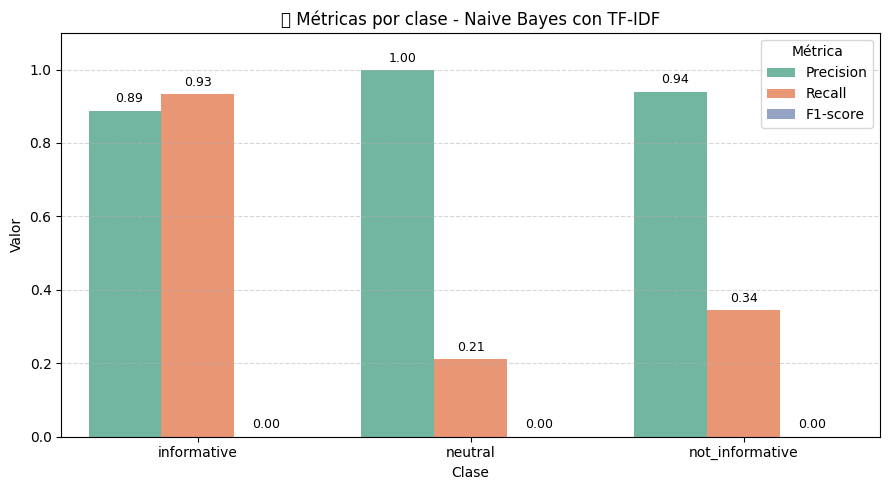

In [188]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np
import pandas as pd

# Métricas
precision_tfidf, recall_tfidf, f1_tfidf, _ = precision_recall_fscore_support(
    y_test_enc_tfidf, y_pred_tfidf, zero_division=0
)

# DataFrame
metrics_df_tfidf = pd.DataFrame({
    'Clase': np.repeat(le_tfidf.classes_, 3),
    'Métrica': ['Precision', 'Recall', 'F1-score'] * len(le_tfidf.classes_),
    'Valor': np.concatenate([precision_tfidf, recall_tfidf, f1_tfidf])
})

# Gráfico
plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_df_tfidf, x='Clase', y='Valor', hue='Métrica', palette='Set2')

# Anotaciones
for i in range(len(metrics_df_tfidf)):
    row = metrics_df_tfidf.iloc[i]
    plt.text(i // 3 + (i % 3 - 1) * 0.25, row['Valor'] + 0.015, f"{row['Valor']:.2f}",
             ha='center', va='bottom', fontsize=9)

plt.title("📈 Métricas por clase - Naive Bayes con TF-IDF")
plt.ylim(0, 1.1)
plt.ylabel("Valor")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Support Vector Machine with BoW

### SVM

In [189]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# 1. Filtrar datos válidos
df_valid = df[df['clean_text'].notnull() & df['info_label'].notnull()].copy()

# 2. Vectorizador BoW optimizado (solo unigramas)
vectorizer_bow = CountVectorizer(
    stop_words='english',
    max_df=0.95,
    min_df=5,
    max_features=7000
)

X_bow = vectorizer_bow.fit_transform(df_valid['clean_text'])
y = df_valid['info_label'].values
split = df_valid['split'].values

# 3. Separar en train/test
X_train = X_bow[split == 'train']
X_test = X_bow[split == 'test']
y_train = y[split == 'train']
y_test = y[split == 'test']

# 4. Codificar etiquetas
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# 5. Entrenar modelo SVM lineal
svm_model = LinearSVC(class_weight='balanced', max_iter=5000)
svm_model.fit(X_train, y_train_enc)

# 6. Predicción y evaluación
y_pred_svm = svm_model.predict(X_test)

print("🔍 Reporte de clasificación - SVM con BoW:")
print(classification_report(y_test_enc, y_pred_svm, target_names=le.classes_))

print("📉 Matriz de confusión - SVM con BoW:")
print(confusion_matrix(y_test_enc, y_pred_svm))

🔍 Reporte de clasificación - SVM con BoW:
                 precision    recall  f1-score   support

    informative       0.93      0.91      0.92      1256
        neutral       0.60      0.64      0.62       133
not_informative       0.19      0.26      0.22        53

       accuracy                           0.86      1442
      macro avg       0.58      0.60      0.59      1442
   weighted avg       0.87      0.86      0.87      1442

📉 Matriz de confusión - SVM con BoW:
[[1145   53   58]
 [  47   85    1]
 [  36    3   14]]


Matriz de Confusión

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\715248996.py:19: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


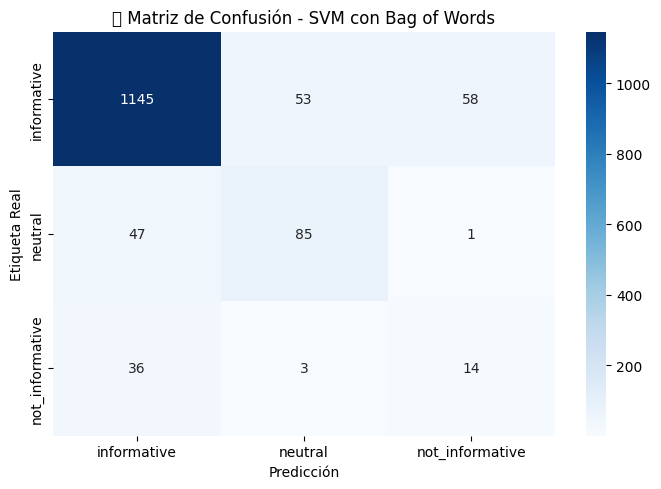

In [190]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Etiquetas en texto
y_test_labels_svm = le.inverse_transform(y_test_enc)
y_pred_labels_svm = le.inverse_transform(y_pred_svm)

# Matriz de confusión
cm_svm = confusion_matrix(y_test_labels_svm, y_pred_labels_svm, labels=le.classes_)

# Visualización
plt.figure(figsize=(7, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("📊 Matriz de Confusión - SVM con Bag of Words")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Real")
plt.tight_layout()
plt.show()

Métricas por clase

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\3511776473.py:31: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


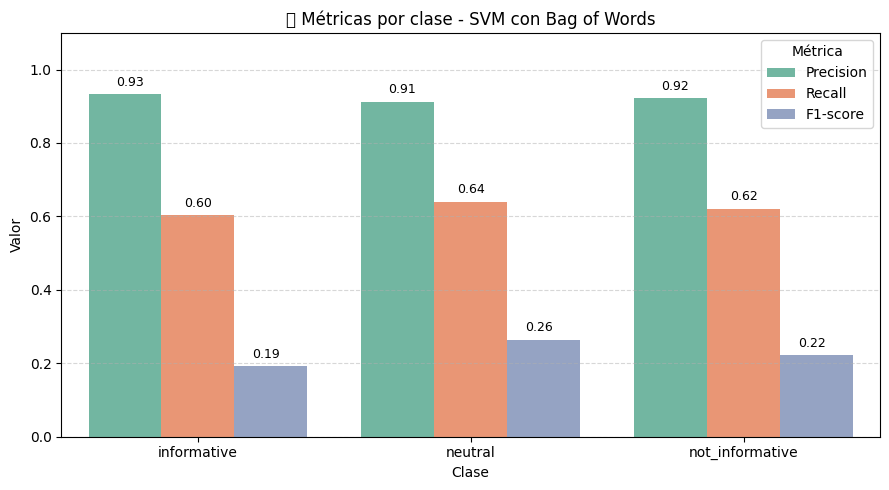

In [191]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np
import pandas as pd

# Calcular métricas
precision_svm, recall_svm, f1_svm, _ = precision_recall_fscore_support(
    y_test_enc, y_pred_svm, zero_division=0
)

# DataFrame
metrics_df_svm = pd.DataFrame({
    'Clase': np.repeat(le.classes_, 3),
    'Métrica': ['Precision', 'Recall', 'F1-score'] * len(le.classes_),
    'Valor': np.concatenate([precision_svm, recall_svm, f1_svm])
})

# Gráfico
plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_df_svm, x='Clase', y='Valor', hue='Métrica', palette='Set2')

# Anotar valores
for i in range(len(metrics_df_svm)):
    row = metrics_df_svm.iloc[i]
    plt.text(i // 3 + (i % 3 - 1) * 0.25, row['Valor'] + 0.015, f"{row['Valor']:.2f}",
             ha='center', va='bottom', fontsize=9)

plt.title("📈 Métricas por clase - SVM con Bag of Words")
plt.ylim(0, 1.1)
plt.ylabel("Valor")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### SVM con BoW y n-grams(1,2)

In [192]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# 1. Filtrar datos válidos
df_valid = df[df['clean_text'].notnull() & df['info_label'].notnull()].copy()

# 2. Vectorizador BoW con n-grams (1,2)
vectorizer_ng = CountVectorizer(
    ngram_range=(1, 2),
    stop_words='english',
    max_df=0.95,
    min_df=5,
    max_features=10000  # puedes ajustar
)

X_ng = vectorizer_ng.fit_transform(df_valid['clean_text'])
y = df_valid['info_label'].values
split = df_valid['split'].values

# 3. Dividir en train/test
X_train_ng = X_ng[split == 'train']
X_test_ng = X_ng[split == 'test']
y_train_ng = y[split == 'train']
y_test_ng = y[split == 'test']

# 4. Codificar etiquetas
le_ng = LabelEncoder()
y_train_enc_ng = le_ng.fit_transform(y_train_ng)
y_test_enc_ng = le_ng.transform(y_test_ng)

# 5. Entrenar modelo SVM
svm_model_ng = LinearSVC(class_weight='balanced', max_iter=5000)
svm_model_ng.fit(X_train_ng, y_train_enc_ng)

# 6. Predicción y evaluación
y_pred_svm_ng = svm_model_ng.predict(X_test_ng)

print("🔍 Reporte de clasificación - SVM con n-grams (1,2):")
print(classification_report(y_test_enc_ng, y_pred_svm_ng, target_names=le_ng.classes_))

print("📉 Matriz de confusión - SVM con n-grams (1,2):")
print(confusion_matrix(y_test_enc_ng, y_pred_svm_ng))

🔍 Reporte de clasificación - SVM con n-grams (1,2):
                 precision    recall  f1-score   support

    informative       0.93      0.92      0.92      1256
        neutral       0.63      0.59      0.61       133
not_informative       0.17      0.21      0.19        53

       accuracy                           0.87      1442
      macro avg       0.58      0.58      0.57      1442
   weighted avg       0.87      0.87      0.87      1442

📉 Matriz de confusión - SVM con n-grams (1,2):
[[1160   44   52]
 [  54   79    0]
 [  39    3   11]]


Matriz de confusión

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\1522436966.py:19: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


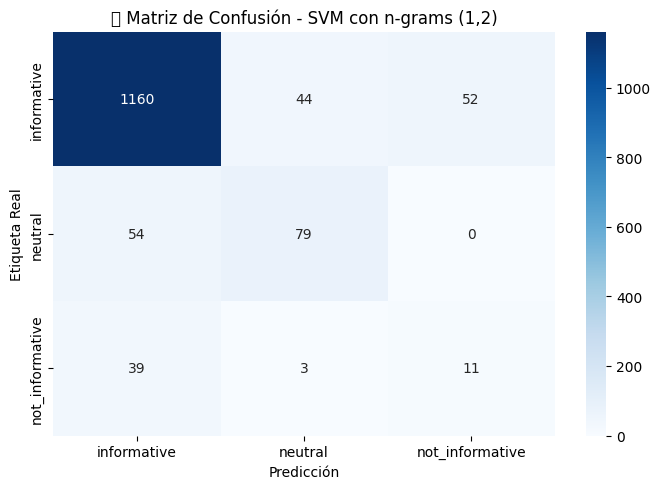

In [193]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Convertir etiquetas codificadas a texto
y_test_labels_ng = le_ng.inverse_transform(y_test_enc_ng)
y_pred_labels_ng = le_ng.inverse_transform(y_pred_svm_ng)

# Matriz de confusión
cm_svm_ng = confusion_matrix(y_test_labels_ng, y_pred_labels_ng, labels=le_ng.classes_)

# Visualización con seaborn
plt.figure(figsize=(7, 5))
sns.heatmap(cm_svm_ng, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_ng.classes_, yticklabels=le_ng.classes_)
plt.title("📊 Matriz de Confusión - SVM con n-grams (1,2)")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Real")
plt.tight_layout()
plt.show()

Métricas por clase

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\3211113755.py:31: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


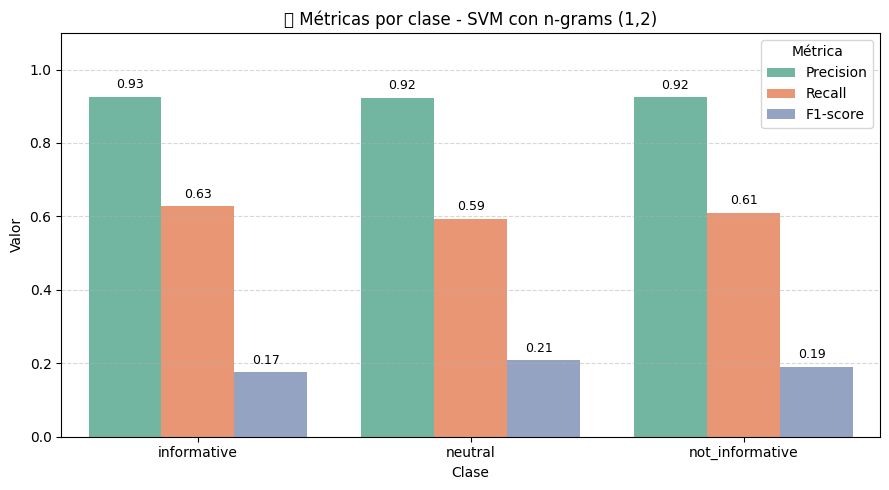

In [194]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np
import pandas as pd

# Obtener métricas
precision_svm_ng, recall_svm_ng, f1_svm_ng, _ = precision_recall_fscore_support(
    y_test_enc_ng, y_pred_svm_ng, zero_division=0
)

# Crear DataFrame
metrics_df_svm_ng = pd.DataFrame({
    'Clase': np.repeat(le_ng.classes_, 3),
    'Métrica': ['Precision', 'Recall', 'F1-score'] * len(le_ng.classes_),
    'Valor': np.concatenate([precision_svm_ng, recall_svm_ng, f1_svm_ng])
})

# Visualización
plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_df_svm_ng, x='Clase', y='Valor', hue='Métrica', palette='Set2')

# Anotar valores sobre barras
for i in range(len(metrics_df_svm_ng)):
    row = metrics_df_svm_ng.iloc[i]
    plt.text(i // 3 + (i % 3 - 1) * 0.25, row['Valor'] + 0.015, f"{row['Valor']:.2f}",
             ha='center', va='bottom', fontsize=9)

plt.title("📈 Métricas por clase - SVM con n-grams (1,2)")
plt.ylim(0, 1.1)
plt.ylabel("Valor")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### SVM con TF-IDF

In [195]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# 1. Filtrar datos válidos
df_valid = df[df['clean_text'].notnull() & df['info_label'].notnull()].copy()

# 2. TF-IDF vectorizer
vectorizer_tfidf = TfidfVectorizer(
    stop_words='english',
    max_df=0.95,
    min_df=5,
    max_features=7000,
    ngram_range=(1, 1)  # unigramas
)

X_tfidf = vectorizer_tfidf.fit_transform(df_valid['clean_text'])
y = df_valid['info_label'].values
split = df_valid['split'].values

# 3. Separar en train/test
X_train_tfidf = X_tfidf[split == 'train']
X_test_tfidf = X_tfidf[split == 'test']
y_train_tfidf = y[split == 'train']
y_test_tfidf = y[split == 'test']

# 4. Codificar etiquetas
le_tfidf = LabelEncoder()
y_train_enc_tfidf = le_tfidf.fit_transform(y_train_tfidf)
y_test_enc_tfidf = le_tfidf.transform(y_test_tfidf)

# 5. Entrenar modelo SVM
svm_model_tfidf = LinearSVC(class_weight='balanced', max_iter=5000)
svm_model_tfidf.fit(X_train_tfidf, y_train_enc_tfidf)

# 6. Predicción y evaluación
y_pred_svm_tfidf = svm_model_tfidf.predict(X_test_tfidf)

print("🔍 Reporte de clasificación - SVM con TF-IDF:")
print(classification_report(y_test_enc_tfidf, y_pred_svm_tfidf, target_names=le_tfidf.classes_))

print("📉 Matriz de confusión - SVM con TF-IDF:")
print(confusion_matrix(y_test_enc_tfidf, y_pred_svm_tfidf))

🔍 Reporte de clasificación - SVM con TF-IDF:
                 precision    recall  f1-score   support

    informative       0.93      0.93      0.93      1256
        neutral       0.68      0.62      0.65       133
not_informative       0.23      0.26      0.25        53

       accuracy                           0.88      1442
      macro avg       0.61      0.61      0.61      1442
   weighted avg       0.88      0.88      0.88      1442

📉 Matriz de confusión - SVM con TF-IDF:
[[1174   37   45]
 [  50   82    1]
 [  37    2   14]]


Matriz de confusión

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\604428755.py:19: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


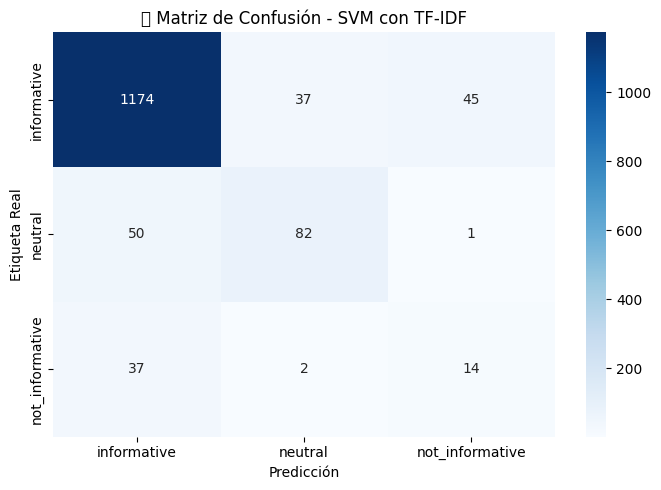

In [196]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Etiquetas como texto
y_test_labels_svm_tfidf = le_tfidf.inverse_transform(y_test_enc_tfidf)
y_pred_labels_svm_tfidf = le_tfidf.inverse_transform(y_pred_svm_tfidf)

# Matriz de confusión
cm_svm_tfidf = confusion_matrix(y_test_labels_svm_tfidf, y_pred_labels_svm_tfidf, labels=le_tfidf.classes_)

# Visualización
plt.figure(figsize=(7, 5))
sns.heatmap(cm_svm_tfidf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_tfidf.classes_, yticklabels=le_tfidf.classes_)
plt.title("📊 Matriz de Confusión - SVM con TF-IDF")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Real")
plt.tight_layout()
plt.show()

Métricas por clase

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\1143018037.py:31: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


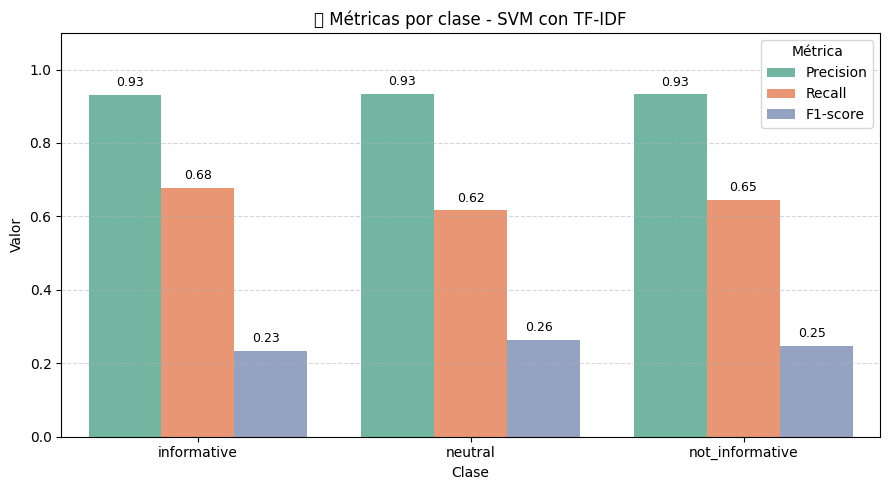

In [197]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np
import pandas as pd

# Calcular métricas
precision_svm_tfidf, recall_svm_tfidf, f1_svm_tfidf, _ = precision_recall_fscore_support(
    y_test_enc_tfidf, y_pred_svm_tfidf, zero_division=0
)

# DataFrame
metrics_df_svm_tfidf = pd.DataFrame({
    'Clase': np.repeat(le_tfidf.classes_, 3),
    'Métrica': ['Precision', 'Recall', 'F1-score'] * len(le_tfidf.classes_),
    'Valor': np.concatenate([precision_svm_tfidf, recall_svm_tfidf, f1_svm_tfidf])
})

# Visualización
plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_df_svm_tfidf, x='Clase', y='Valor', hue='Métrica', palette='Set2')

# Anotar valores
for i in range(len(metrics_df_svm_tfidf)):
    row = metrics_df_svm_tfidf.iloc[i]
    plt.text(i // 3 + (i % 3 - 1) * 0.25, row['Valor'] + 0.015, f"{row['Valor']:.2f}",
             ha='center', va='bottom', fontsize=9)

plt.title("📈 Métricas por clase - SVM con TF-IDF")
plt.ylim(0, 1.1)
plt.ylabel("Valor")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Logistic Regression

### Logistic Regression with BoW

In [198]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# 1. Filtrar datos válidos
df_valid = df[df['clean_text'].notnull() & df['info_label'].notnull()].copy()

# 2. Vectorizador BoW con parámetros ajustados
vectorizer_lr = CountVectorizer(
    stop_words='english',
    max_df=0.95,
    min_df=5,
    max_features=7000,
    ngram_range=(1, 1)  # solo unigramas
)

X_lr = vectorizer_lr.fit_transform(df_valid['clean_text'])
y = df_valid['info_label'].values
split = df_valid['split'].values

# 3. Separar datos en train/test
X_train_lr = X_lr[split == 'train']
X_test_lr = X_lr[split == 'test']
y_train_lr = y[split == 'train']
y_test_lr = y[split == 'test']

# 4. Codificar etiquetas
le_lr = LabelEncoder()
y_train_enc_lr = le_lr.fit_transform(y_train_lr)
y_test_enc_lr = le_lr.transform(y_test_lr)

# 5. Crear y entrenar el modelo de regresión logística
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='liblinear',  # o 'saga' si tuvieras más clases
    multi_class='ovr'
)
lr_model.fit(X_train_lr, y_train_enc_lr)

# 6. Predicción y evaluación
y_pred_lr = lr_model.predict(X_test_lr)

print("🔍 Reporte de clasificación - Logistic Regression (BoW):")
print(classification_report(y_test_enc_lr, y_pred_lr, target_names=le_lr.classes_))

print("📉 Matriz de confusión - Logistic Regression (BoW):")
print(confusion_matrix(y_test_enc_lr, y_pred_lr))

🔍 Reporte de clasificación - Logistic Regression (BoW):
                 precision    recall  f1-score   support

    informative       0.93      0.94      0.94      1256
        neutral       0.67      0.63      0.65       133
not_informative       0.25      0.26      0.26        53

       accuracy                           0.89      1442
      macro avg       0.62      0.61      0.61      1442
   weighted avg       0.89      0.89      0.89      1442

📉 Matriz de confusión - Logistic Regression (BoW):
[[1179   37   40]
 [  47   84    2]
 [  35    4   14]]


c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Matriz de confusión

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\3585127574.py:19: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


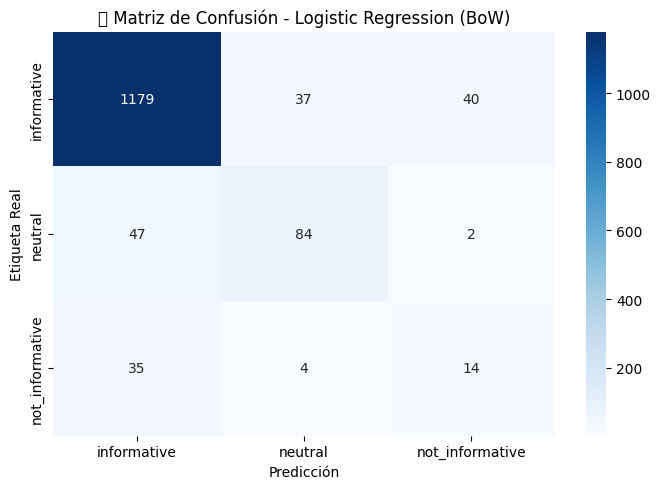

In [199]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Convertir etiquetas codificadas a texto
y_test_labels_lr = le_lr.inverse_transform(y_test_enc_lr)
y_pred_labels_lr = le_lr.inverse_transform(y_pred_lr)

# Matriz de confusión
cm_lr = confusion_matrix(y_test_labels_lr, y_pred_labels_lr, labels=le_lr.classes_)

# Visualización con seaborn
plt.figure(figsize=(7, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_lr.classes_, yticklabels=le_lr.classes_)
plt.title("📊 Matriz de Confusión - Logistic Regression (BoW)")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Real")
plt.tight_layout()
plt.show()

Métricas por clase

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\2892374378.py:31: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


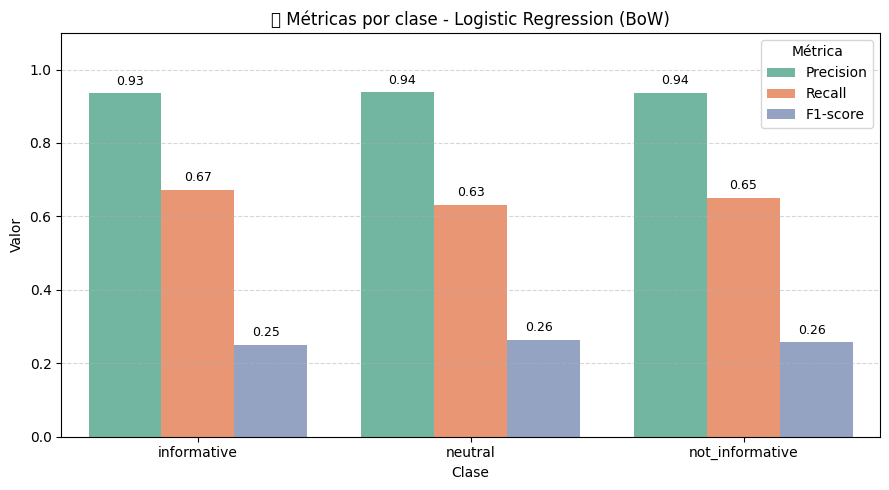

In [200]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np
import pandas as pd

# Calcular métricas
precision_lr, recall_lr, f1_lr, _ = precision_recall_fscore_support(
    y_test_enc_lr, y_pred_lr, zero_division=0
)

# Crear DataFrame para visualización
metrics_df_lr = pd.DataFrame({
    'Clase': np.repeat(le_lr.classes_, 3),
    'Métrica': ['Precision', 'Recall', 'F1-score'] * len(le_lr.classes_),
    'Valor': np.concatenate([precision_lr, recall_lr, f1_lr])
})

# Gráfico de barras
plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_df_lr, x='Clase', y='Valor', hue='Métrica', palette='Set2')

# Anotar valores
for i in range(len(metrics_df_lr)):
    row = metrics_df_lr.iloc[i]
    plt.text(i // 3 + (i % 3 - 1) * 0.25, row['Valor'] + 0.015, f"{row['Valor']:.2f}",
             ha='center', va='bottom', fontsize=9)

plt.title("📈 Métricas por clase - Logistic Regression (BoW)")
plt.ylim(0, 1.1)
plt.ylabel("Valor")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Logistic Regression con BoW + n-grams (1,2)

In [201]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# 1. Filtrar datos válidos
df_valid = df[df['clean_text'].notnull() & df['info_label'].notnull()].copy()

# 2. Vectorizador BoW con n-grams (1,2)
vectorizer_ng = CountVectorizer(
    stop_words='english',
    max_df=0.95,
    min_df=5,
    max_features=10000,
    ngram_range=(1, 2)  # unigramas + bigramas
)

X_lr_ng = vectorizer_ng.fit_transform(df_valid['clean_text'])
y = df_valid['info_label'].values
split = df_valid['split'].values

# 3. Separar en train/test
X_train_lr_ng = X_lr_ng[split == 'train']
X_test_lr_ng = X_lr_ng[split == 'test']
y_train_lr_ng = y[split == 'train']
y_test_lr_ng = y[split == 'test']

# 4. Codificar etiquetas
le_lr_ng = LabelEncoder()
y_train_enc_lr_ng = le_lr_ng.fit_transform(y_train_lr_ng)
y_test_enc_lr_ng = le_lr_ng.transform(y_test_lr_ng)

# 5. Entrenar modelo Logistic Regression
lr_model_ng = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='liblinear',
    multi_class='ovr'
)
lr_model_ng.fit(X_train_lr_ng, y_train_enc_lr_ng)

# 6. Predicción y evaluación
y_pred_lr_ng = lr_model_ng.predict(X_test_lr_ng)

print("🔍 Reporte de clasificación - Logistic Regression con n-grams (1,2):")
print(classification_report(y_test_enc_lr_ng, y_pred_lr_ng, target_names=le_lr_ng.classes_))

print("📉 Matriz de confusión:")
print(confusion_matrix(y_test_enc_lr_ng, y_pred_lr_ng))


c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


🔍 Reporte de clasificación - Logistic Regression con n-grams (1,2):
                 precision    recall  f1-score   support

    informative       0.93      0.95      0.94      1256
        neutral       0.70      0.59      0.64       133
not_informative       0.26      0.23      0.24        53

       accuracy                           0.89      1442
      macro avg       0.63      0.59      0.60      1442
   weighted avg       0.88      0.89      0.88      1442

📉 Matriz de confusión:
[[1191   31   34]
 [  54   78    1]
 [  38    3   12]]


Matriz de confusión

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\1298704936.py:19: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


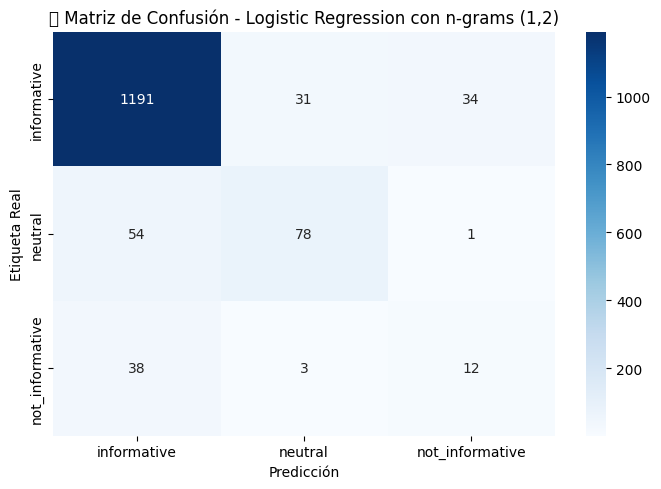

In [202]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Convertir etiquetas codificadas a texto
y_test_labels_lr_ng = le_lr_ng.inverse_transform(y_test_enc_lr_ng)
y_pred_labels_lr_ng = le_lr_ng.inverse_transform(y_pred_lr_ng)

# Matriz de confusión
cm_lr_ng = confusion_matrix(y_test_labels_lr_ng, y_pred_labels_lr_ng, labels=le_lr_ng.classes_)

# Visualización
plt.figure(figsize=(7, 5))
sns.heatmap(cm_lr_ng, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_lr_ng.classes_, yticklabels=le_lr_ng.classes_)
plt.title("📊 Matriz de Confusión - Logistic Regression con n-grams (1,2)")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Real")
plt.tight_layout()
plt.show()

Métricas por clase

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\755262800.py:31: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


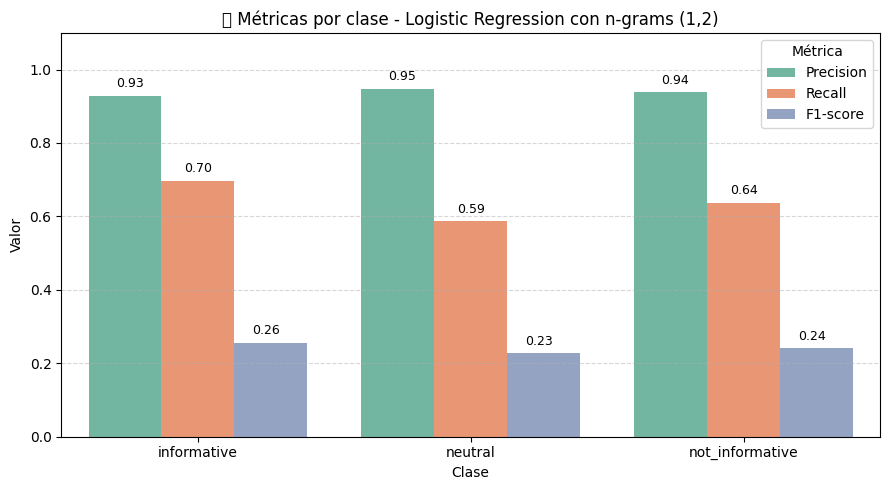

In [203]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np
import pandas as pd

# Calcular métricas por clase
precision_lr_ng, recall_lr_ng, f1_lr_ng, _ = precision_recall_fscore_support(
    y_test_enc_lr_ng, y_pred_lr_ng, zero_division=0
)

# DataFrame para visualización
metrics_df_lr_ng = pd.DataFrame({
    'Clase': np.repeat(le_lr_ng.classes_, 3),
    'Métrica': ['Precision', 'Recall', 'F1-score'] * len(le_lr_ng.classes_),
    'Valor': np.concatenate([precision_lr_ng, recall_lr_ng, f1_lr_ng])
})

# Visualización
plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_df_lr_ng, x='Clase', y='Valor', hue='Métrica', palette='Set2')

# Anotar valores
for i in range(len(metrics_df_lr_ng)):
    row = metrics_df_lr_ng.iloc[i]
    plt.text(i // 3 + (i % 3 - 1) * 0.25, row['Valor'] + 0.015, f"{row['Valor']:.2f}",
             ha='center', va='bottom', fontsize=9)

plt.title("📈 Métricas por clase - Logistic Regression con n-grams (1,2)")
plt.ylim(0, 1.1)
plt.ylabel("Valor")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Logistic Regression con TF-IDF

In [204]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# 1. Filtrar datos válidos
df_valid = df[df['clean_text'].notnull() & df['info_label'].notnull()].copy()

# 2. Vectorización con TF-IDF
vectorizer_tfidf_lr = TfidfVectorizer(
    stop_words='english',
    max_df=0.95,
    min_df=5,
    max_features=10000,
    ngram_range=(1, 1)  # solo unigramas para empezar
)

X_tfidf_lr = vectorizer_tfidf_lr.fit_transform(df_valid['clean_text'])
y = df_valid['info_label'].values
split = df_valid['split'].values

# 3. Separar datos
X_train_tfidf_lr = X_tfidf_lr[split == 'train']
X_test_tfidf_lr = X_tfidf_lr[split == 'test']
y_train_tfidf_lr = y[split == 'train']
y_test_tfidf_lr = y[split == 'test']

# 4. Codificar etiquetas
le_tfidf_lr = LabelEncoder()
y_train_enc_tfidf_lr = le_tfidf_lr.fit_transform(y_train_tfidf_lr)
y_test_enc_tfidf_lr = le_tfidf_lr.transform(y_test_tfidf_lr)

# 5. Modelo de Regresión Logística
lr_model_tfidf = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='liblinear',
    multi_class='ovr'
)
lr_model_tfidf.fit(X_train_tfidf_lr, y_train_enc_tfidf_lr)

# 6. Evaluación
y_pred_tfidf_lr = lr_model_tfidf.predict(X_test_tfidf_lr)

print("🔍 Reporte de clasificación - Logistic Regression con TF-IDF:")
print(classification_report(y_test_enc_tfidf_lr, y_pred_tfidf_lr, target_names=le_tfidf_lr.classes_))

print("📉 Matriz de confusión:")
print(confusion_matrix(y_test_enc_tfidf_lr, y_pred_tfidf_lr))

🔍 Reporte de clasificación - Logistic Regression con TF-IDF:
                 precision    recall  f1-score   support

    informative       0.92      0.96      0.94      1256
        neutral       0.72      0.55      0.62       133
not_informative       0.28      0.17      0.21        53

       accuracy                           0.89      1442
      macro avg       0.64      0.56      0.59      1442
   weighted avg       0.88      0.89      0.89      1442

📉 Matriz de confusión:
[[1207   26   23]
 [  60   73    0]
 [  41    3    9]]


c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Matriz de confusion

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\1020603143.py:19: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


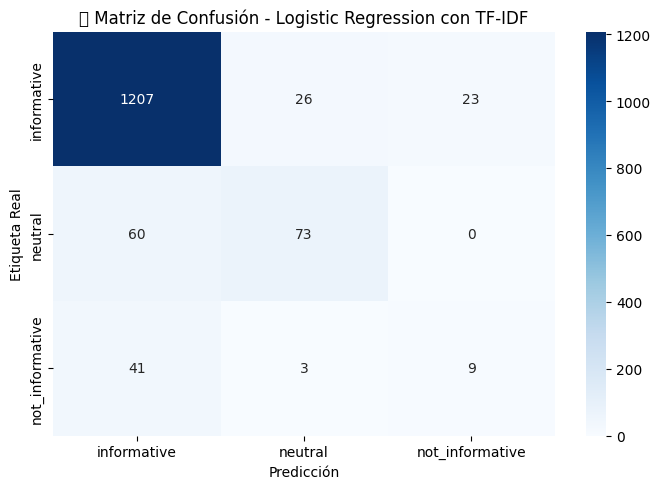

In [205]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Convertir etiquetas codificadas a texto
y_test_labels_tfidf_lr = le_tfidf_lr.inverse_transform(y_test_enc_tfidf_lr)
y_pred_labels_tfidf_lr = le_tfidf_lr.inverse_transform(y_pred_tfidf_lr)

# Matriz de confusión
cm_tfidf_lr = confusion_matrix(y_test_labels_tfidf_lr, y_pred_labels_tfidf_lr, labels=le_tfidf_lr.classes_)

# Visualización con seaborn
plt.figure(figsize=(7, 5))
sns.heatmap(cm_tfidf_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_tfidf_lr.classes_, yticklabels=le_tfidf_lr.classes_)
plt.title("📊 Matriz de Confusión - Logistic Regression con TF-IDF")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Real")
plt.tight_layout()
plt.show()

Métricas por clase

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\1045351029.py:31: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


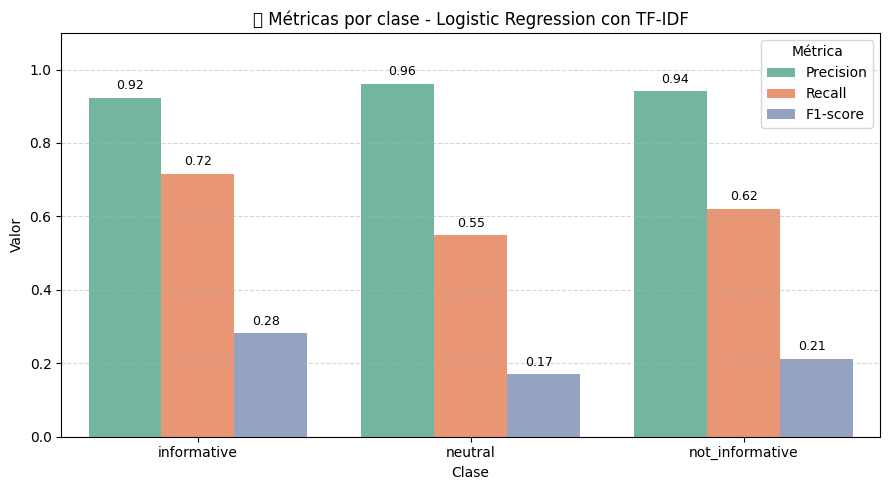

In [206]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np
import pandas as pd

# Calcular métricas por clase
precision_tfidf_lr, recall_tfidf_lr, f1_tfidf_lr, _ = precision_recall_fscore_support(
    y_test_enc_tfidf_lr, y_pred_tfidf_lr, zero_division=0
)

# DataFrame para visualización
metrics_df_tfidf_lr = pd.DataFrame({
    'Clase': np.repeat(le_tfidf_lr.classes_, 3),
    'Métrica': ['Precision', 'Recall', 'F1-score'] * len(le_tfidf_lr.classes_),
    'Valor': np.concatenate([precision_tfidf_lr, recall_tfidf_lr, f1_tfidf_lr])
})

# Visualización
plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_df_tfidf_lr, x='Clase', y='Valor', hue='Métrica', palette='Set2')

# Anotar valores en las barras
for i in range(len(metrics_df_tfidf_lr)):
    row = metrics_df_tfidf_lr.iloc[i]
    plt.text(i // 3 + (i % 3 - 1) * 0.25, row['Valor'] + 0.015, f"{row['Valor']:.2f}",
             ha='center', va='bottom', fontsize=9)

plt.title("📈 Métricas por clase - Logistic Regression con TF-IDF")
plt.ylim(0, 1.1)
plt.ylabel("Valor")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Comparación entre los modelos

Tabla comparativa

In [207]:
import pandas as pd

# Crear DataFrame con resultados resumidos
resultados_modelos = pd.DataFrame([
    {"Modelo": "Naive Bayes (BoW)", "Accuracy": 0.88, "F1_macro": 0.58, "F1_weighted": 0.88},
    {"Modelo": "Naive Bayes (BoW + n-grams)", "Accuracy": 0.87, "F1_macro": 0.57, "F1_weighted": 0.87},
    {"Modelo": "Naive Bayes (TF-IDF)", "Accuracy": 0.89, "F1_macro": 0.43, "F1_weighted": 0.85},

    {"Modelo": "SVM (BoW)", "Accuracy": 0.86, "F1_macro": 0.59, "F1_weighted": 0.87},
    {"Modelo": "SVM (BoW + n-grams)", "Accuracy": 0.87, "F1_macro": 0.57, "F1_weighted": 0.87},
    {"Modelo": "SVM (TF-IDF)", "Accuracy": 0.88, "F1_macro": 0.61, "F1_weighted": 0.88},

    {"Modelo": "Logistic Regression (BoW)", "Accuracy": 0.89, "F1_macro": 0.61, "F1_weighted": 0.89},
    {"Modelo": "Logistic Regression (BoW + n-grams)", "Accuracy": 0.89, "F1_macro": 0.60, "F1_weighted": 0.88},
    {"Modelo": "Logistic Regression (TF-IDF)", "Accuracy": 0.89, "F1_macro": 0.59, "F1_weighted": 0.89},
])

# Mostrar tabla
resultados_modelos

,Modelo,Accuracy,F1_macro,F1_weighted
0,Naive Bayes (BoW),0.88,0.58,0.88
1,Naive Bayes (BoW + n-grams),0.87,0.57,0.87
2,Naive Bayes (TF-IDF),0.89,0.43,0.85
3,SVM (BoW),0.86,0.59,0.87
4,SVM (BoW + n-grams),0.87,0.57,0.87
5,SVM (TF-IDF),0.88,0.61,0.88
6,Logistic Regression (BoW),0.89,0.61,0.89
7,Logistic Regression (BoW + n-grams),0.89,0.60,0.88
8,Logistic Regression (TF-IDF),0.89,0.59,0.89


Gráfico comparativo

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\2545448073.py:13: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


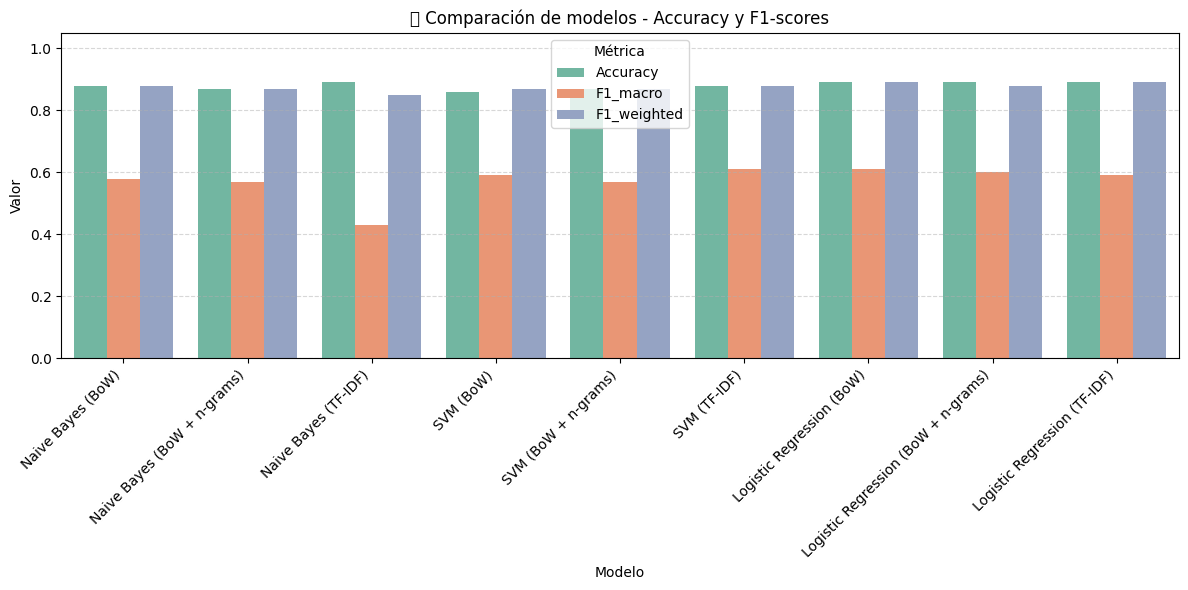

In [208]:
import seaborn as sns
import matplotlib.pyplot as plt

# Gráfico de barras múltiples
resultados_melted = resultados_modelos.melt(id_vars="Modelo", var_name="Métrica", value_name="Valor")

plt.figure(figsize=(12, 6))
sns.barplot(data=resultados_melted, x="Modelo", y="Valor", hue="Métrica", palette="Set2")
plt.xticks(rotation=45, ha="right")
plt.title("📊 Comparación de modelos - Accuracy y F1-scores")
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Redes Neuronales

### Modelo base

Importa Librerías

In [209]:
!pip install tensorflow --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas 2.1.4 requires numpy<2,>=1.23.2; python_version == "3.11", but you have numpy 2.1.3 which is incompatible.
scikit-learn 1.3.2 requires numpy<2.0,>=1.17.3, but you have numpy 2.1.3 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Librerías necesarias

In [210]:
# Librerías base
import numpy as np
import pandas as pd

# Preprocesamiento de texto y etiquetas
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Construcción del modelo neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Flatten

# Evaluación
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

Preparar los textos y etiquetas

In [211]:
texts = df['tweet_text'].astype(str).values
labels = df['info_label'].values

Codificar las etiquetas (info_label) a enteros y luego one-hot

In [212]:
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
labels_cat = to_categorical(labels_encoded, num_classes=3)

Tokenización

In [213]:
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

Padding (rellenar para que todos tengan la misma longitud)

In [214]:
max_length = 50
X = pad_sequences(sequences, maxlen=max_length, padding='post')
y = labels_cat

División en entrenamiento y prueba

In [215]:
# División de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

Construcción del modelo secuencial

In [216]:
# Definición del modelo neuronal
model = Sequential()
model.add(Embedding(input_dim=10000, output_dim=64, input_length=50))  # 10k vocabulario, 64 dimensiones
model.add(Flatten())  # Aplana la salida del embedding
model.add(Dense(128, activation='relu'))  # Capa intermedia
model.add(Dense(3, activation='softmax'))  # Capa de salida (3 clases)

# Compilar el modelo
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Ver resumen del modelo
model.summary()

c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Entrenamiento del modelo

In [217]:
# Entrenamiento del modelo
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8381 - loss: 0.5126 - val_accuracy: 0.8902 - val_loss: 0.3218
Epoch 2/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9125 - loss: 0.2410 - val_accuracy: 0.8988 - val_loss: 0.3122
Epoch 3/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9824 - loss: 0.0661 - val_accuracy: 0.8988 - val_loss: 0.3405
Epoch 4/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9972 - loss: 0.0147 - val_accuracy: 0.8919 - val_loss: 0.3794
Epoch 5/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9991 - loss: 0.0039 - val_accuracy: 0.9074 - val_loss: 0.4155
Epoch 6/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.9039 - val_loss: 0.4329
Epoch 7/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 6.4566e-04 - val_accuracy: 0.9039 - val_loss: 0.4538
Epoch 8/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 3.8044e-04 - val_accu

Evaluación del modelo

In [218]:
# Evaluación y métricas
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Reporte de clasificación
print(classification_report(y_true, y_pred, target_names=le.classes_))

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
                 precision    recall  f1-score   support

    informative       0.93      0.97      0.95      1268
        neutral       0.77      0.66      0.71       134
not_informative       0.29      0.07      0.12        54

       accuracy                           0.91      1456
      macro avg       0.66      0.57      0.59      1456
   weighted avg       0.89      0.91      0.90      1456



Matriz de confusión

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\3339712661.py:13: UserWarning: Glyph 128311 (\N{LARGE BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128311 (\N{LARGE BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


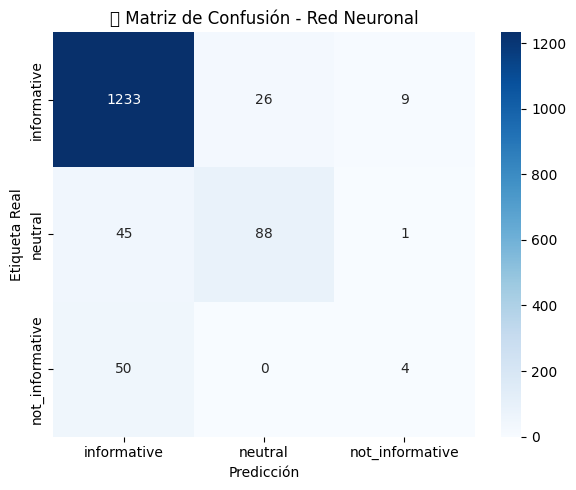

In [219]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("🔷 Matriz de Confusión - Red Neuronal")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Real")
plt.tight_layout()
plt.show()

Métricas por clase

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\2042754779.py:17: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


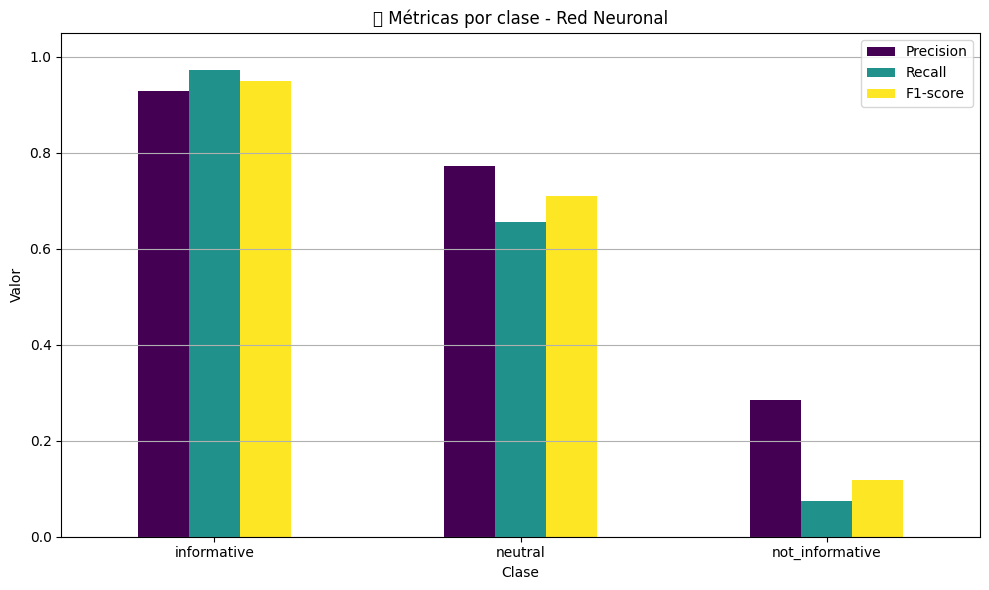

In [220]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred)
class_metrics = pd.DataFrame({
    'Clase': le.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1
})

class_metrics.set_index('Clase').plot(kind='bar', figsize=(10,6), colormap='viridis')
plt.title("📊 Métricas por clase - Red Neuronal")
plt.ylim(0, 1.05)
plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Gráfica de precisión y pérdida por época

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\4123236550.py:10: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


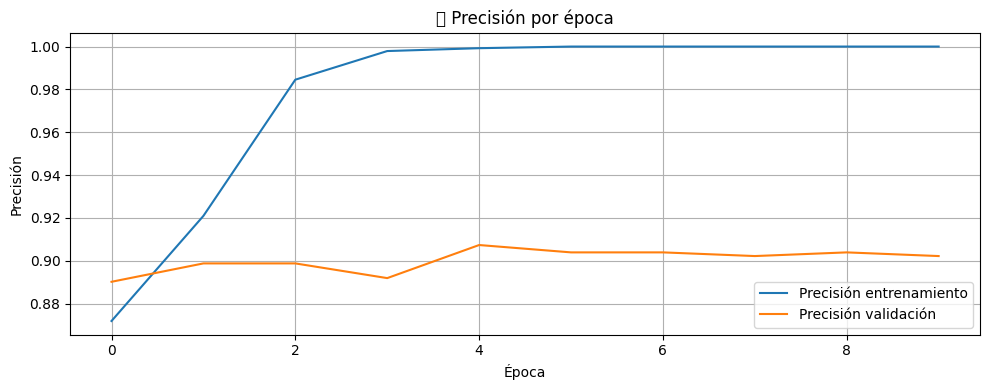

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\4123236550.py:22: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


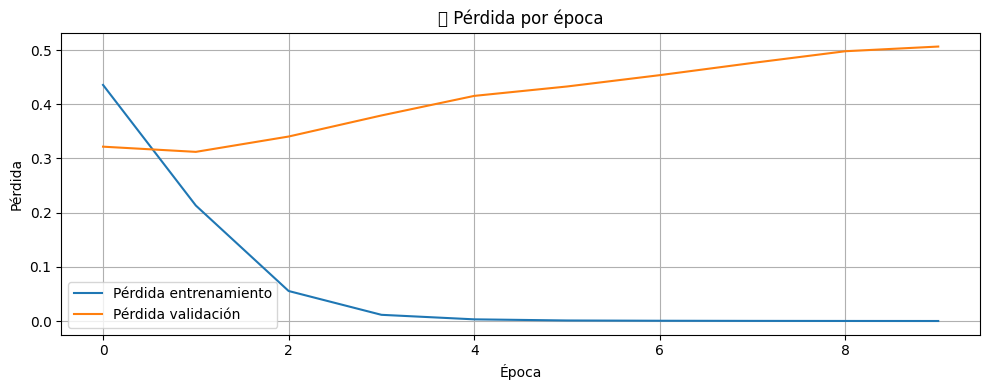

In [221]:
# Precisión
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Precisión entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión validación')
plt.title('📈 Precisión por época')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Pérdida
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Pérdida entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida validación')
plt.title('📉 Pérdida por época')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Redes Neuronales con Dropout, Regularización L2 y class_weight

Construcción del modelo mejorado

In [222]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Dropout, Flatten
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# Arquitectura mejorada
model = Sequential()
model.add(Embedding(input_dim=10000, output_dim=64, input_length=max_length))
model.add(Flatten())
model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dropout(0.3))
model.add(Dense(3, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

model.summary()

c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Definir pesos para clases desbalanceadas

In [223]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Reconvertimos etiquetas originales a enteros para calcular pesos
y_train_int = np.argmax(y_train, axis=1)

# Calcular los pesos inversos a la frecuencia de las clases
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)

# Convertir a diccionario
class_weights_dict = dict(enumerate(class_weights))
print("Pesos de clase:", class_weights_dict)

Pesos de clase: {0: np.float64(0.3829255459089713), 1: np.float64(3.607187112763321), 2: np.float64(8.984567901234568)}


Entrenamiento del modelo con class_weight

In [224]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weights_dict,
    verbose=1
)

Epoch 1/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3275 - loss: 2.4530 - val_accuracy: 0.2796 - val_loss: 1.1858
Epoch 2/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1798 - loss: 1.1501 - val_accuracy: 0.2127 - val_loss: 1.0762
Epoch 3/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5030 - loss: 0.7944 - val_accuracy: 0.6690 - val_loss: 0.9516
Epoch 4/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7736 - loss: 0.5655 - val_accuracy: 0.7976 - val_loss: 0.7205
Epoch 5/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8926 - loss: 0.4062 - val_accuracy: 0.7787 - val_loss: 0.7388
Epoch 6/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9244 - loss: 0.3335 - val_accuracy: 0.8422 - val_loss: 0.6475
Epoch 7/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9483 - loss: 0.2925 - val_accuracy: 0.8799 - val_loss: 0.5599
Epoch 8/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9606 - loss: 0.2457 - val_accuracy: 0.

Evaluación y visualización

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
🔍 Reporte de clasificación - Red Neuronal Mejorada:
                 precision    recall  f1-score   support

    informative       0.93      0.89      0.91      1268
        neutral       0.68      0.67      0.68       134
not_informative       0.14      0.31      0.20        54

       accuracy                           0.85      1456
      macro avg       0.59      0.62      0.59      1456
   weighted avg       0.88      0.85      0.86      1456



C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\925191532.py:27: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


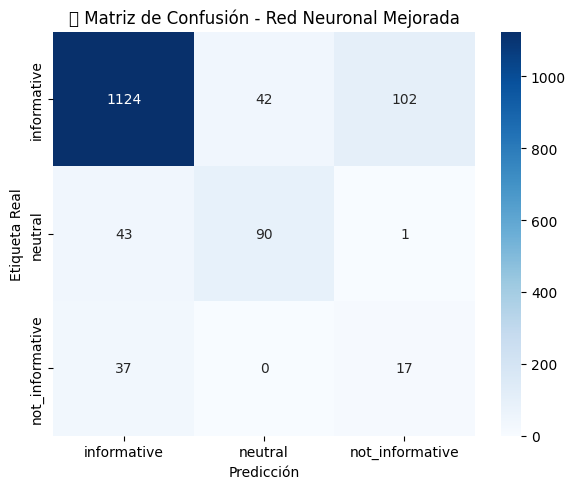

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\925191532.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


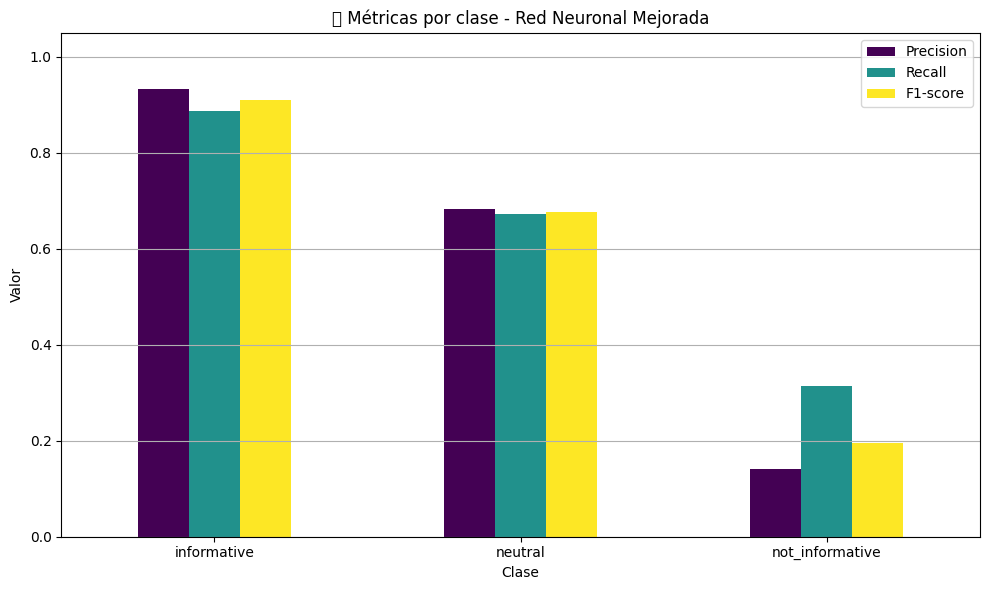

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\925191532.py:57: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


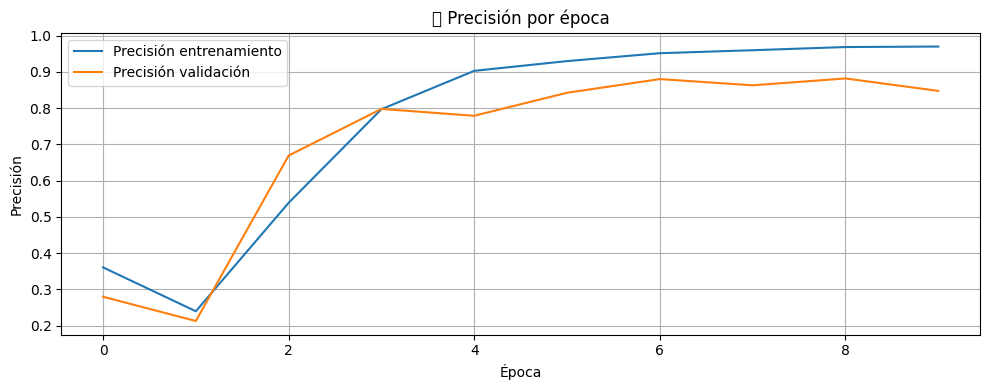

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\925191532.py:69: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


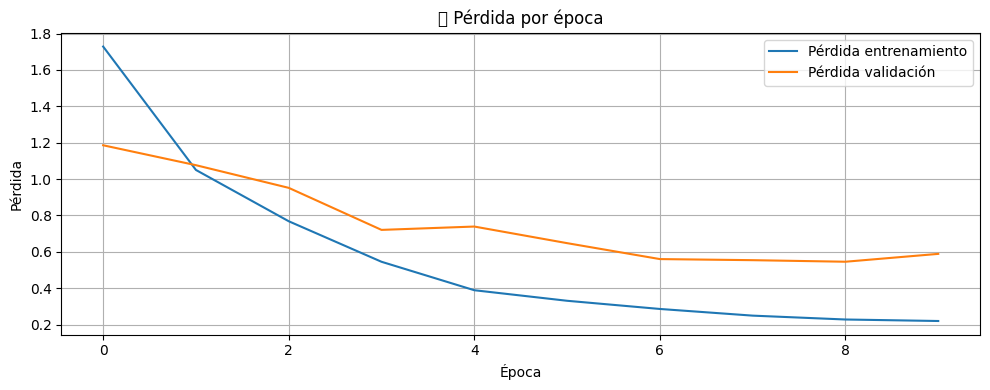

In [225]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import pandas as pd

# Predicciones
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Reporte de clasificación
from sklearn.metrics import classification_report, precision_recall_fscore_support

target_names = le.classes_  # Si usaste LabelEncoder
print("🔍 Reporte de clasificación - Red Neuronal Mejorada:")
print(classification_report(y_true_labels, y_pred_labels, target_names=target_names))

# Matriz de confusión
conf_mat = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title("📉 Matriz de Confusión - Red Neuronal Mejorada")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Real")
plt.tight_layout()
plt.show()

# Métricas por clase
precision, recall, f1, _ = precision_recall_fscore_support(y_true_labels, y_pred_labels)
metrics_df = pd.DataFrame({
    'Clase': target_names,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1
})

metrics_df.set_index('Clase').plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title("📈 Métricas por clase - Red Neuronal Mejorada")
plt.ylim(0, 1.05)
plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Gráfica de precisión por época
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Precisión entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión validación')
plt.title("📈 Precisión por época")
plt.xlabel("Época")
plt.ylabel("Precisión")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfica de pérdida por época
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Pérdida entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida validación')
plt.title("📉 Pérdida por época")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Comparaciones finales

,Modelo,Accuracy,F1_macro,F1_weighted
0,Naive Bayes (BoW),0.88,0.58,0.88
1,Naive Bayes (n-grams),0.87,0.57,0.87
2,Naive Bayes (TF-IDF),0.89,0.43,0.85
3,SVM (BoW),0.86,0.59,0.87
4,SVM (n-grams),0.87,0.57,0.87
5,SVM (TF-IDF),0.88,0.61,0.88
6,Logistic Regression (BoW),0.89,0.61,0.89
7,Logistic Regression (n-grams),0.89,0.60,0.88
8,Logistic Regression (TF-IDF),0.89,0.59,0.89
9,Red Neuronal (simple),0.91,0.57,0.89


C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\152464425.py:34: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


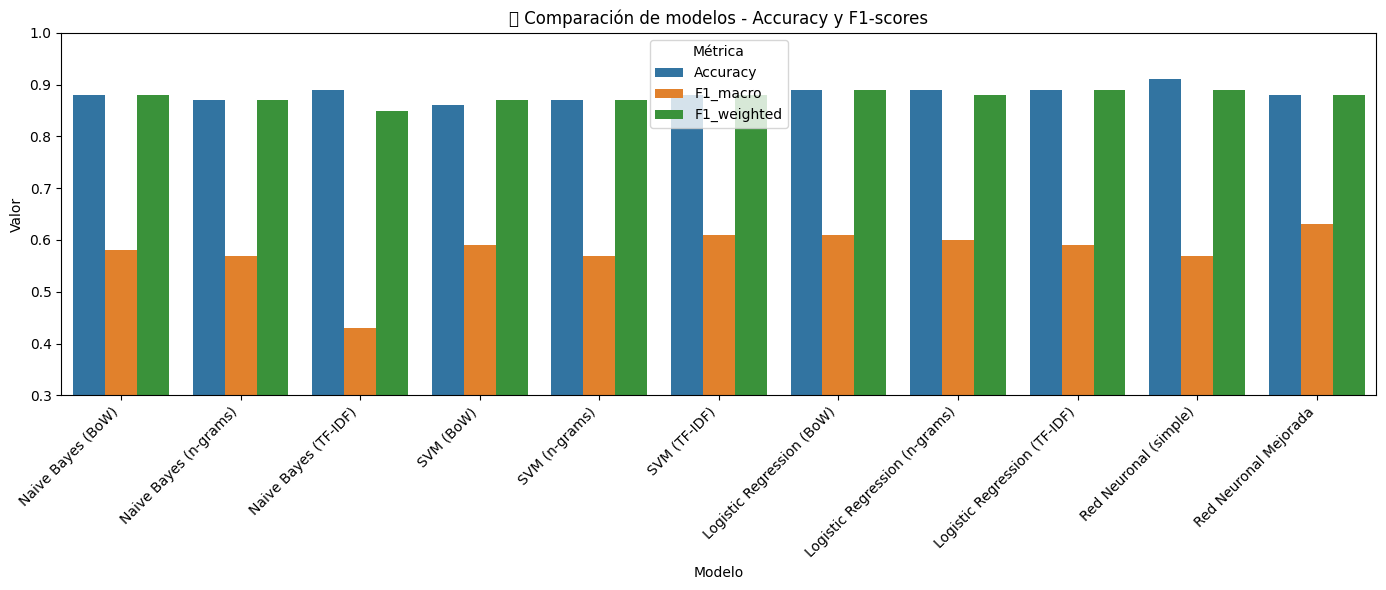

In [226]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Datos de comparación (rellena con tus propios resultados si deseas actualizar)
data_modelos = [
    {'Modelo': 'Naive Bayes (BoW)', 'Accuracy': 0.88, 'F1_macro': 0.58, 'F1_weighted': 0.88},
    {'Modelo': 'Naive Bayes (n-grams)', 'Accuracy': 0.87, 'F1_macro': 0.57, 'F1_weighted': 0.87},
    {'Modelo': 'Naive Bayes (TF-IDF)', 'Accuracy': 0.89, 'F1_macro': 0.43, 'F1_weighted': 0.85},
    {'Modelo': 'SVM (BoW)', 'Accuracy': 0.86, 'F1_macro': 0.59, 'F1_weighted': 0.87},
    {'Modelo': 'SVM (n-grams)', 'Accuracy': 0.87, 'F1_macro': 0.57, 'F1_weighted': 0.87},
    {'Modelo': 'SVM (TF-IDF)', 'Accuracy': 0.88, 'F1_macro': 0.61, 'F1_weighted': 0.88},
    {'Modelo': 'Logistic Regression (BoW)', 'Accuracy': 0.89, 'F1_macro': 0.61, 'F1_weighted': 0.89},
    {'Modelo': 'Logistic Regression (n-grams)', 'Accuracy': 0.89, 'F1_macro': 0.60, 'F1_weighted': 0.88},
    {'Modelo': 'Logistic Regression (TF-IDF)', 'Accuracy': 0.89, 'F1_macro': 0.59, 'F1_weighted': 0.89},
    {'Modelo': 'Red Neuronal (simple)', 'Accuracy': 0.91, 'F1_macro': 0.57, 'F1_weighted': 0.89},
    {'Modelo': 'Red Neuronal Mejorada', 'Accuracy': 0.88, 'F1_macro': 0.63, 'F1_weighted': 0.88},
]

df_modelos = pd.DataFrame(data_modelos)

# Mostrar tabla
from IPython.display import display
display(df_modelos)

# Gráfica comparativa
plt.figure(figsize=(14, 6))
df_melted = df_modelos.melt(id_vars='Modelo', value_vars=['Accuracy', 'F1_macro', 'F1_weighted'],
                            var_name='Métrica', value_name='Valor')
sns.barplot(data=df_melted, x='Modelo', y='Valor', hue='Métrica')
plt.title("🔍 Comparación de modelos - Accuracy y F1-scores")
plt.xticks(rotation=45, ha='right')
plt.ylim(0.3, 1.0)
plt.tight_layout()
plt.show()

# Modelo de Clasificación Mejorado

## Análisis Exploratorio de los datos por cada Huracán

### Huracán Dorian 2019

Cargar librerías

In [227]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Cargar los datos del huracán Dorian 2019

Train


,tweet_id,tweet_text,class_label
0,1167883326872375298,Super important ahead of Hurricane Dorian - sh...,sympathy_and_support
1,1168209055086764044,As Category 5 Hurricane Dorian impacts the Bah...,other_relevant_information
2,1168320199407394816,"Bird, Lime, Spin and Jump sent their hurricane...",other_relevant_information
3,1167538295972216838,The District continues to monitor #HurricaneDo...,caution_and_advice
4,1167626335440855042,At this time all cilivan search and rescue tea...,rescue_volunteering_or_donation_effort


Dev


,tweet_id,tweet_text,class_label
0,1167956030132604928,Everywhere else during a hurricane: lets get f...,not_humanitarian
1,1168178492242051074,Hurricane #Dorian is currently over the Abaco ...,caution_and_advice
2,1168133829426655233,Terrible situation unfolding for the Bahamas. ...,other_relevant_information
3,1168287489230016513,absolutely gutted about what #HopeTown and the...,sympathy_and_support
4,1168234287478345729,Happy Dorian Eve! Prepare for the worst!,caution_and_advice


Test


,tweet_id,tweet_text,class_label
0,1168139805810728960,SOUTH FLORIDA: Portions of #Broward and #PalmB...,caution_and_advice
1,1168146392474427392,RT @NSMTheLegend: The perfection of the eye in...,other_relevant_information
2,1168172616349290496,Palm Beach County orders partial evacuation as...,displaced_people_and_evacuations
3,1168161831669514241,@deAdder if i could draw or control an outcome...,not_humanitarian
4,1167515384657907713,Hurricane DORIAN is coming! AdvantaClean offer...,infrastructure_and_utility_damage


Train shape: (5329, 3)
Dev shape: (776, 3)
Test shape: (1508, 3)

Columnas:
Index(['tweet_id', 'tweet_text', 'class_label'], dtype='object')


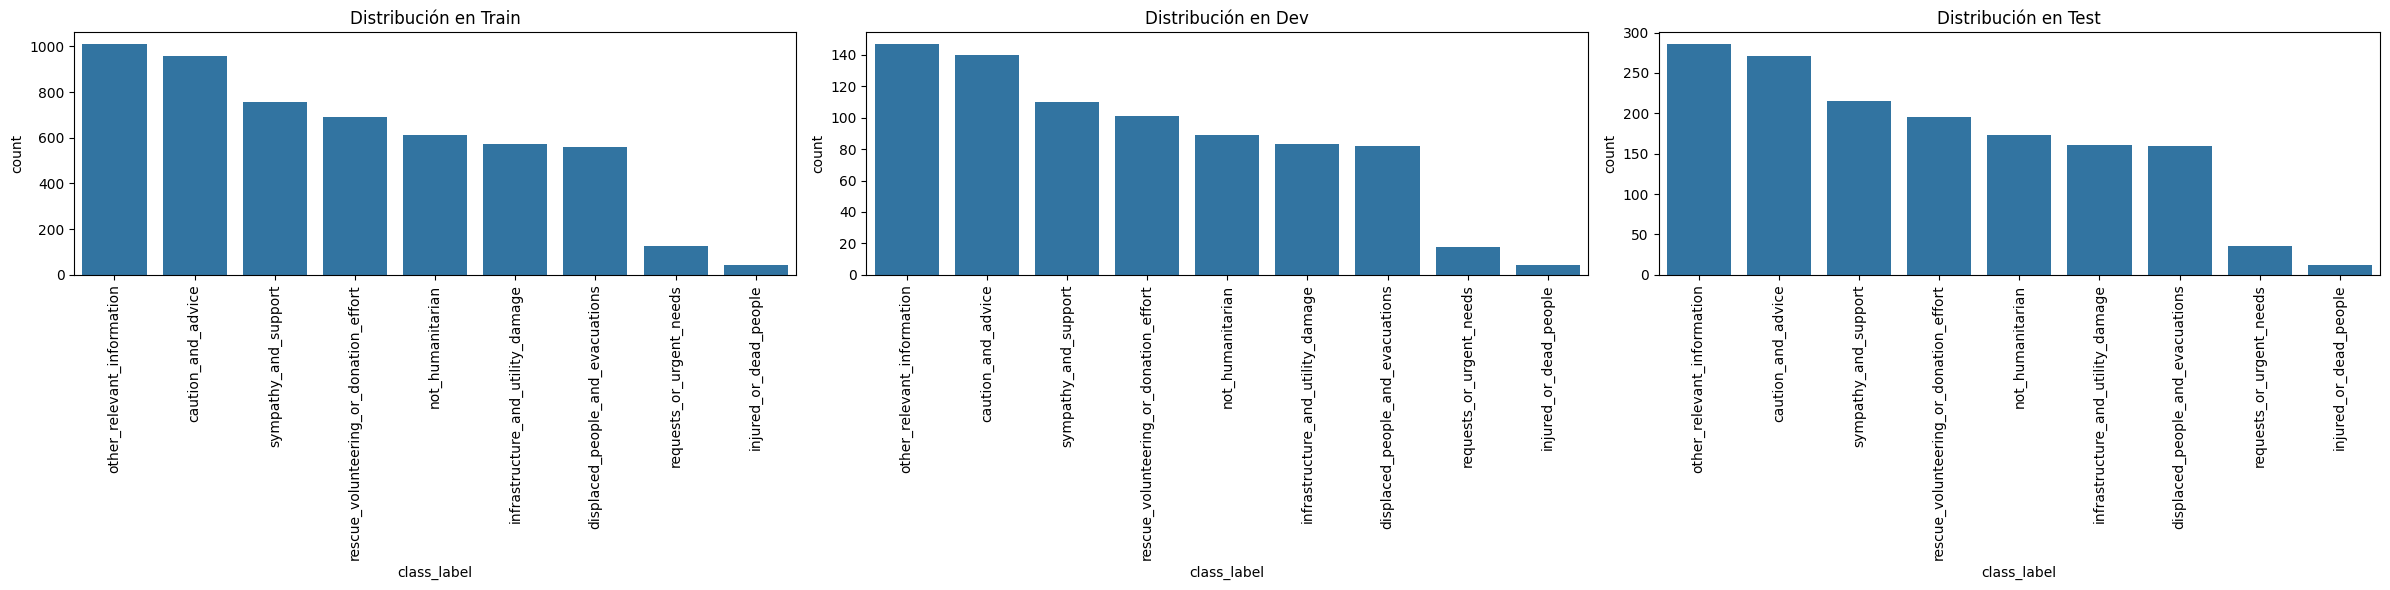

In [228]:
# URLs directas a los archivos .tsv crudos desde GitHub
url_train = "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_dorian_2019/hurricane_dorian_2019_train.tsv"
url_dev = "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_dorian_2019/hurricane_dorian_2019_dev.tsv"
url_test = "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_dorian_2019/hurricane_dorian_2019_test.tsv"

# Cargar en DataFrames
df_train = pd.read_csv(url_train, sep="\t")
df_dev = pd.read_csv(url_dev, sep="\t")
df_test = pd.read_csv(url_test, sep="\t")

# Ver primeras filas de cada conjunto
print("Train")
display(df_train.head())

print("Dev")
display(df_dev.head())

print("Test")
display(df_test.head())

print(f"Train shape: {df_train.shape}")
print(f"Dev shape: {df_dev.shape}")
print(f"Test shape: {df_test.shape}")

print("\nColumnas:")
print(df_train.columns)

# Crear una figura con 3 subgráficos (uno por conjunto)
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Gráfica para Train
sns.countplot(x='class_label', data=df_train, ax=axes[0],
              order=df_train['class_label'].value_counts().index)
axes[0].set_title('Distribución en Train')
axes[0].tick_params(axis='x', rotation=90)

# Gráfica para Dev
sns.countplot(x='class_label', data=df_dev, ax=axes[1],
              order=df_dev['class_label'].value_counts().index)
axes[1].set_title('Distribución en Dev')
axes[1].tick_params(axis='x', rotation=90)

# Gráfica para Test
sns.countplot(x='class_label', data=df_test, ax=axes[2],
              order=df_test['class_label'].value_counts().index)
axes[2].set_title('Distribución en Test')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

Huracán Florence 2018

Train


,tweet_id,tweet_text,class_label
0,1039559767935643648,Mandatory evacuations issued ahead of #Hurrica...,displaced_people_and_evacuations
1,1040557545839108096,RT @iMDRW: The news just said that there are m...,rescue_volunteering_or_donation_effort
2,1041673527978536960,#DONATE today. You can contribute online or by...,rescue_volunteering_or_donation_effort
3,1040709198785536003,"#Florence is now a strong tropical storm, with...",other_relevant_information
4,1041506707166380032,#garyvee says if you want to have the biggest ...,not_humanitarian


Dev


,tweet_id,tweet_text,class_label
0,1041374506365837312,Were #hiring! Read about our latest #job openi...,not_humanitarian
1,1041594735654100997,I am so thankful this guy was able to rescue t...,rescue_volunteering_or_donation_effort
2,1039909240083767297,The NY-TF1 team is currently staged in Kinston...,rescue_volunteering_or_donation_effort
3,1040054715906584576,"See our latest #Utica, NY #job and click to ap...",not_humanitarian
4,1041761221333069824,FLOOD WATCH REMAINS IN EFFECT THROUGH TUESDAY ...,caution_and_advice


Test


,tweet_id,tweet_text,class_label
0,1039897860127551490,"Hurricane Hunters fly Florence, conduct search...",rescue_volunteering_or_donation_effort
1,1040166633761923072,#HurricaneFlorence: Life threatening. Damaging...,infrastructure_and_utility_damage
2,1041221702150180865,‘Epic’ rainfall from Hurricane Florence causin...,other_relevant_information
3,1042024646772588546,@kofc Brooklyn is mobilizing for #HurricaneFlo...,rescue_volunteering_or_donation_effort
4,1041713334679166977,Super thankful for the volunteers sorting and ...,rescue_volunteering_or_donation_effort


Train shape: (4384, 3)
Dev shape: (639, 3)
Test shape: (1241, 3)

Columnas:
Index(['tweet_id', 'tweet_text', 'class_label'], dtype='object')


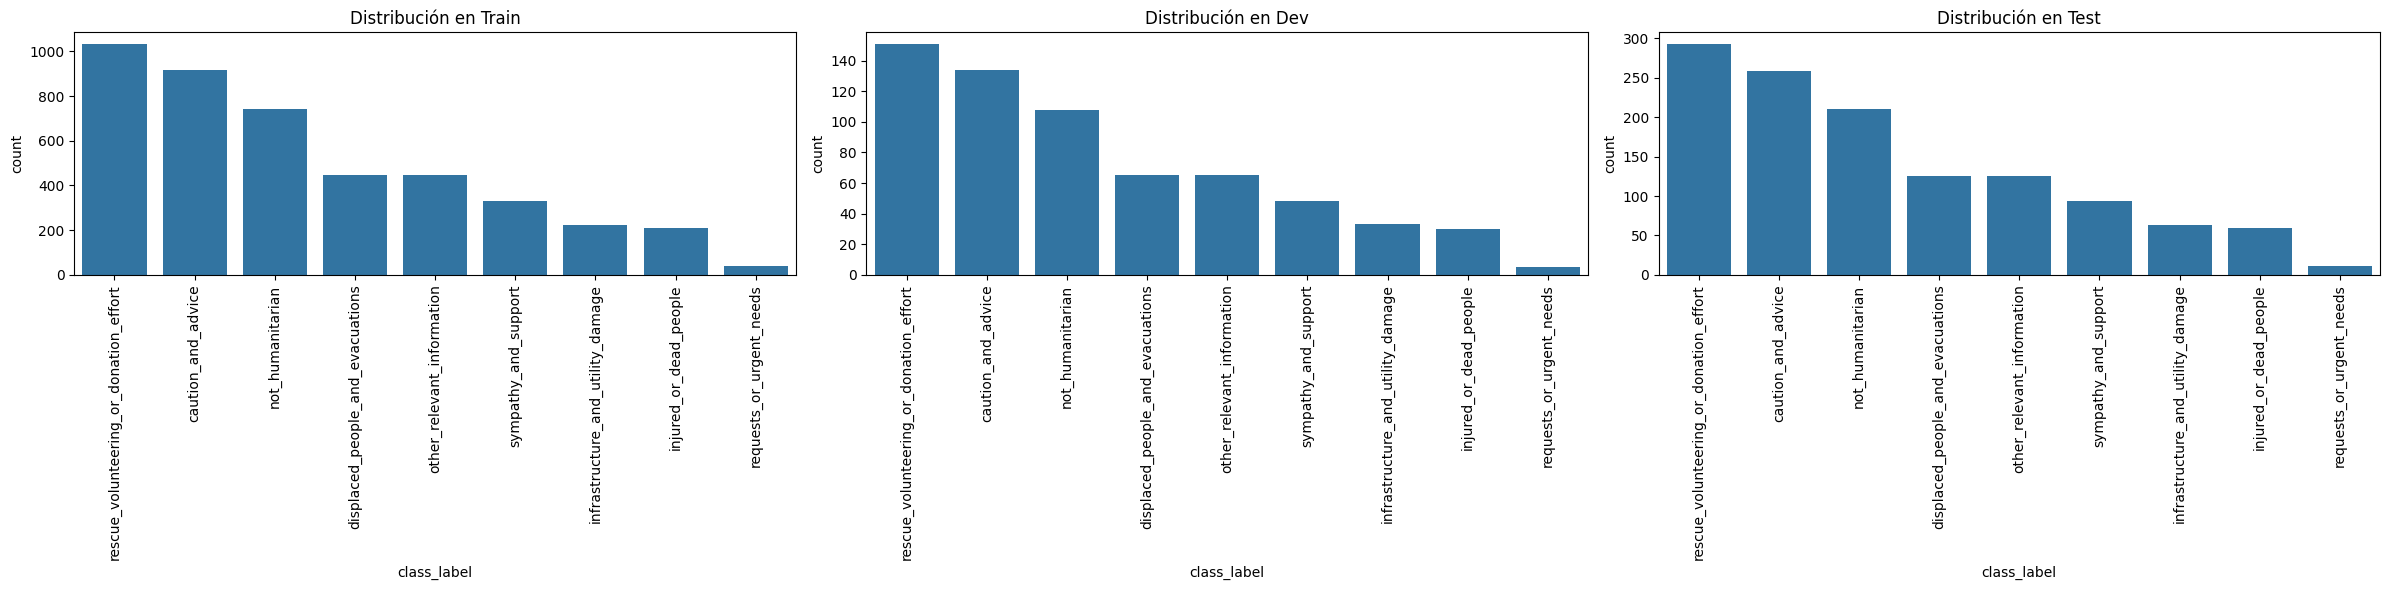

In [229]:
# URLs directas a los archivos .tsv crudos desde GitHub
url_train = 'https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_florence_2018/hurricane_florence_2018_train.tsv'
url_dev = 'https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_florence_2018/hurricane_florence_2018_dev.tsv'
url_test = 'https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_florence_2018/hurricane_florence_2018_test.tsv'

# Cargar en DataFrames
df_train = pd.read_csv(url_train, sep="\t")
df_dev = pd.read_csv(url_dev, sep="\t")
df_test = pd.read_csv(url_test, sep="\t")

# Ver primeras filas de cada conjunto
print("Train")
display(df_train.head())

print("Dev")
display(df_dev.head())

print("Test")
display(df_test.head())

print(f"Train shape: {df_train.shape}")
print(f"Dev shape: {df_dev.shape}")
print(f"Test shape: {df_test.shape}")

print("\nColumnas:")
print(df_train.columns)

# Crear una figura con 3 subgráficos (uno por conjunto)
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Gráfica para Train
sns.countplot(x='class_label', data=df_train, ax=axes[0],
              order=df_train['class_label'].value_counts().index)
axes[0].set_title('Distribución en Train')
axes[0].tick_params(axis='x', rotation=90)

# Gráfica para Dev
sns.countplot(x='class_label', data=df_dev, ax=axes[1],
              order=df_dev['class_label'].value_counts().index)
axes[1].set_title('Distribución en Dev')
axes[1].tick_params(axis='x', rotation=90)

# Gráfica para Test
sns.countplot(x='class_label', data=df_test, ax=axes[2],
              order=df_test['class_label'].value_counts().index)
axes[2].set_title('Distribución en Test')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

### Huracán Harvey 2017

Train


,tweet_id,tweet_text,class_label
0,903388763073720321,"Hurricane Harvey killed at least 38 people, bu...",injured_or_dead_people
1,901136425348759552,Harvey upped to Category 2 hurricane with 110+...,other_relevant_information
2,902853707607535616,A huge shoutout @TexasGuard for all the work y...,rescue_volunteering_or_donation_effort
3,902859729701044224,Our thoughts and prayers are with the people h...,sympathy_and_support
4,901405975856414720,Homes destroyed on Broadway St in Rockport. Pe...,infrastructure_and_utility_damage


Dev


,tweet_id,tweet_text,class_label
0,903468169561489408,"#Harvey has so far cost at least 31 lives, for...",injured_or_dead_people
1,902836318954250240,Grandma getting evacuated on a jet ski! Humans...,displaced_people_and_evacuations
2,901722026527911936,Where are they supposed to go when their homes...,other_relevant_information
3,902897824035201025,But yalls cheeseburgers are more important,not_humanitarian
4,902750379003310080,Resources for filing flood insurance claims - ...,other_relevant_information


Test


,tweet_id,tweet_text,class_label
0,903458068217913345,Can you not use a tragedy that destroyed my co...,infrastructure_and_utility_damage
1,902656565852999680,"After #Harvey, we need to re-think the messagi...",caution_and_advice
2,901671671731560448,A second person was killed on Saturday as Harv...,injured_or_dead_people
3,903446990708723712,DETAILS: #Evacuation order issued for those wi...,displaced_people_and_evacuations
4,902657492966105088,Join us &amp; the @phoenixsaloon for a special...,rescue_volunteering_or_donation_effort


Train shape: (6378, 3)
Dev shape: (929, 3)
Test shape: (1805, 3)

Columnas:
Index(['tweet_id', 'tweet_text', 'class_label'], dtype='object')


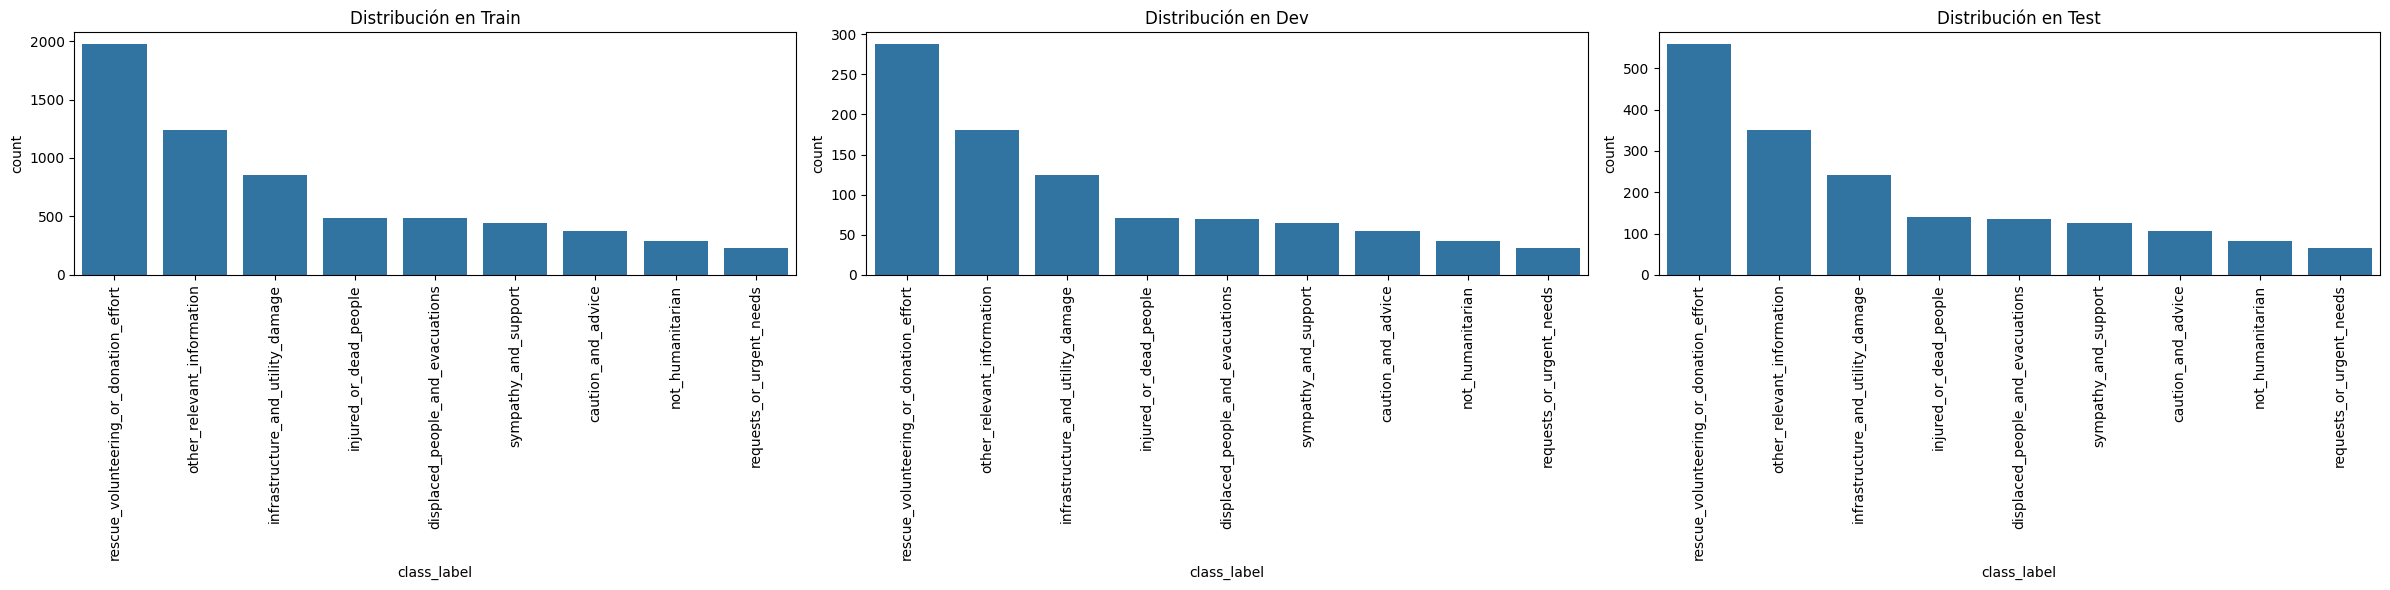

In [230]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# URLs directas a los archivos .tsv de Harvey 2017
url_train = "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_harvey_2017/hurricane_harvey_2017_train.tsv"
url_dev = "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_harvey_2017/hurricane_harvey_2017_dev.tsv"
url_test = "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_harvey_2017/hurricane_harvey_2017_test.tsv"

# Cargar en DataFrames
df_train = pd.read_csv(url_train, sep="\t")
df_dev = pd.read_csv(url_dev, sep="\t")
df_test = pd.read_csv(url_test, sep="\t")

# Ver primeras filas de cada conjunto
print("Train")
display(df_train.head())

print("Dev")
display(df_dev.head())

print("Test")
display(df_test.head())

print(f"Train shape: {df_train.shape}")
print(f"Dev shape: {df_dev.shape}")
print(f"Test shape: {df_test.shape}")

print("\nColumnas:")
print(df_train.columns)

# Crear una figura con 3 subgráficos (uno por conjunto)
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Gráfica para Train
sns.countplot(x='class_label', data=df_train, ax=axes[0],
              order=df_train['class_label'].value_counts().index)
axes[0].set_title('Distribución en Train')
axes[0].tick_params(axis='x', rotation=90)

# Gráfica para Dev
sns.countplot(x='class_label', data=df_dev, ax=axes[1],
              order=df_dev['class_label'].value_counts().index)
axes[1].set_title('Distribución en Dev')
axes[1].tick_params(axis='x', rotation=90)

# Gráfica para Test
sns.countplot(x='class_label', data=df_test, ax=axes[2],
              order=df_test['class_label'].value_counts().index)
axes[2].set_title('Distribución en Test')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

### Huracan Irma 2017

Train


,tweet_id,tweet_text,class_label
0,906347001712926721,An inside look at what its like inside a shelt...,displaced_people_and_evacuations
1,908729925905068032,Our parent company @Realogy is matching $75K f...,rescue_volunteering_or_donation_effort
2,907080161513889792,UNICEF is working to bring safe water &amp; sa...,other_relevant_information
3,906964492193595392,Hurricane Irma ripping entire roofs off buildi...,infrastructure_and_utility_damage
4,907227218593685506,Cosmic Kamer on @richardbranson as he reveals ...,infrastructure_and_utility_damage


Dev


,tweet_id,tweet_text,class_label
0,905546682602885120,Thunderstorms over the Carson Sink will produc...,other_relevant_information
1,906446750784917504,Irma Zeroes in on Florida With $200 Billion Da...,infrastructure_and_utility_damage
2,908746423134388224,@NBCNews @MSNBC WH responds faster to incident...,other_relevant_information
3,908875806071562241,United customers &amp; employees have given $6...,rescue_volunteering_or_donation_effort
4,909416737283612672,RT @OldManRoland_: Aint nobody ask me to help ...,other_relevant_information


Test


,tweet_id,tweet_text,class_label
0,907771445132095488,"Armed with a chainsaw and a charitable spirit,...",other_relevant_information
1,908018116894117889,#StormAileen is bringing #rain in across the w...,caution_and_advice
2,908428954570289154,Tonight in our service we will be collecting t...,other_relevant_information
3,905951544289447936,Its not raining yet but we know you are gettin...,sympathy_and_support
4,905750912702001152,"#Irma update 2: Already, 10 people are dead in...",injured_or_dead_people


Train shape: (6579, 3)
Dev shape: (958, 3)
Test shape: (1862, 3)

Columnas:
Index(['tweet_id', 'tweet_text', 'class_label'], dtype='object')


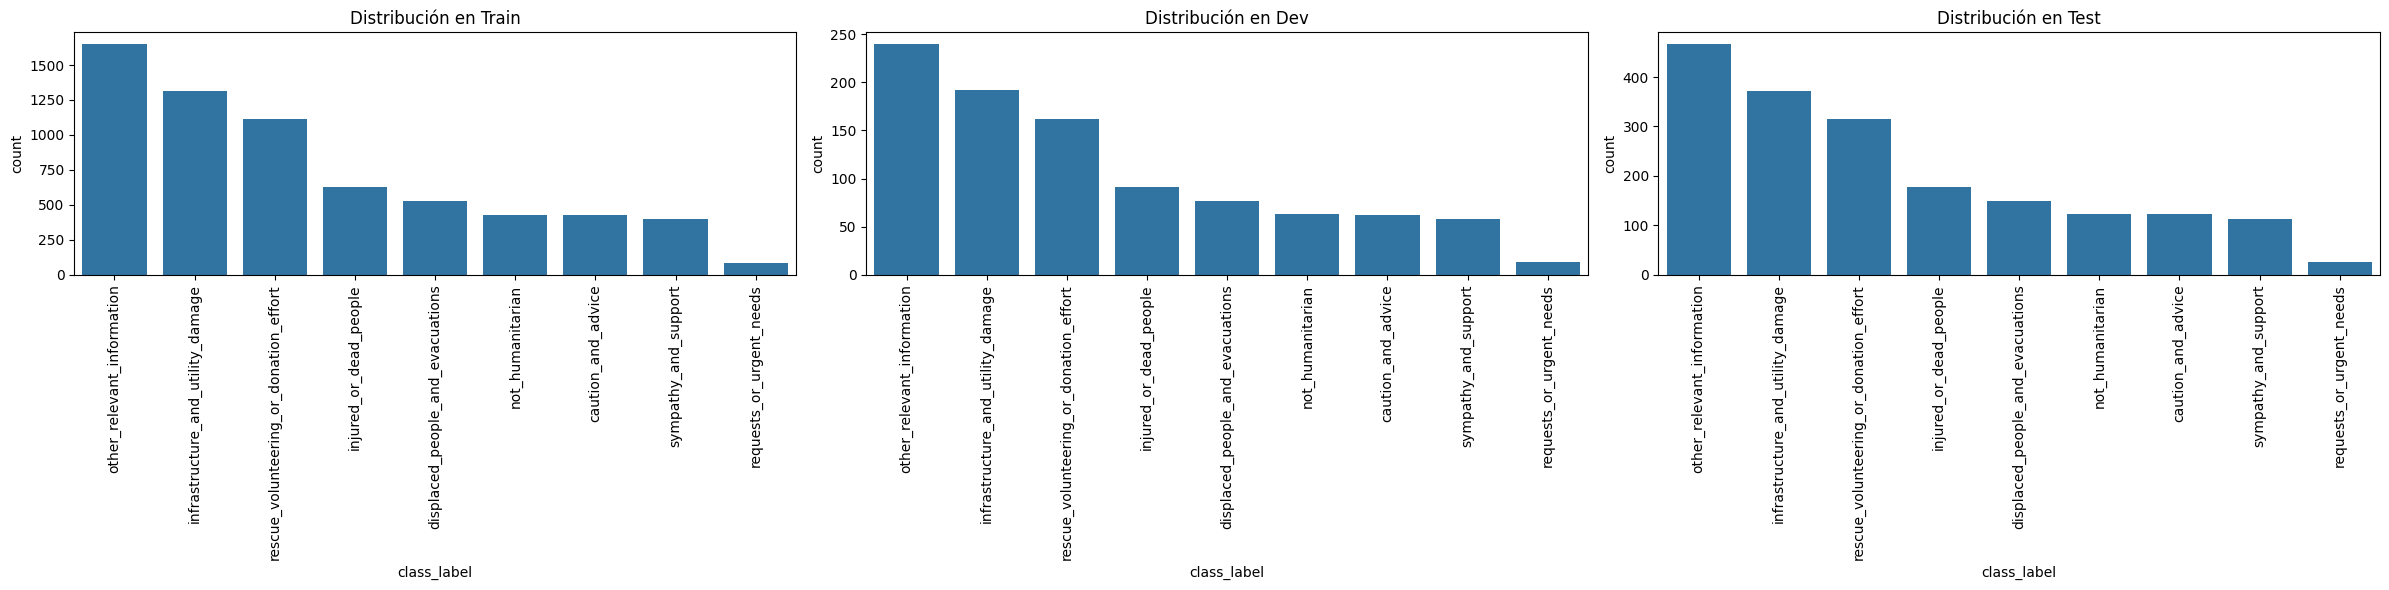

In [231]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# URLs directas a los archivos .tsv de Irma 2017
url_train = "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_irma_2017/hurricane_irma_2017_train.tsv"
url_dev = "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_irma_2017/hurricane_irma_2017_dev.tsv"
url_test = "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_irma_2017/hurricane_irma_2017_test.tsv"

# Cargar en DataFrames
df_train = pd.read_csv(url_train, sep="\t")
df_dev = pd.read_csv(url_dev, sep="\t")
df_test = pd.read_csv(url_test, sep="\t")

# Ver primeras filas de cada conjunto
print("Train")
display(df_train.head())

print("Dev")
display(df_dev.head())

print("Test")
display(df_test.head())

print(f"Train shape: {df_train.shape}")
print(f"Dev shape: {df_dev.shape}")
print(f"Test shape: {df_test.shape}")

print("\nColumnas:")
print(df_train.columns)

# Crear una figura con 3 subgráficos (uno por conjunto)
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Gráfica para Train
sns.countplot(x='class_label', data=df_train, ax=axes[0],
              order=df_train['class_label'].value_counts().index)
axes[0].set_title('Distribución en Train')
axes[0].tick_params(axis='x', rotation=90)

# Gráfica para Dev
sns.countplot(x='class_label', data=df_dev, ax=axes[1],
              order=df_dev['class_label'].value_counts().index)
axes[1].set_title('Distribución en Dev')
axes[1].tick_params(axis='x', rotation=90)

# Gráfica para Test
sns.countplot(x='class_label', data=df_test, ax=axes[2],
              order=df_test['class_label'].value_counts().index)
axes[2].set_title('Distribución en Test')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

Huracán Matthew 2016

Train


,tweet_id,tweet_text,class_label
0,783409770493571076,Horrifying. My heart breaks for Haiti. Thinkin...,sympathy_and_support
1,783683862018818049,Our thoughts and prayers are with those suffer...,sympathy_and_support
2,784696725285908481,#BreakingNews Hurricane Matthew kills over 800...,injured_or_dead_people
3,783549594416377856,Southern Haiti effectively cut off after the b...,other_relevant_information
4,783398732926779392,"Hurricane Matthew hits Haiti, aims at US East ...",other_relevant_information


Dev


,tweet_id,tweet_text,class_label
0,783477557308100609,RT @alyssa__garcia: Everyone tweeting pray for...,sympathy_and_support
1,783741493869699073,RT @CTVToronto: GlobalMedic preparing to go to...,other_relevant_information
2,784648953639931904,RT @MOBILEMIKE_: Aerial footage of western Hai...,infrastructure_and_utility_damage
3,783442390140891136,Our thoughts and prayers are with the people o...,sympathy_and_support
4,783475241452462085,Still raining. Thankful for a hurricane that m...,other_relevant_information


Test


,tweet_id,tweet_text,class_label
0,783416933311971328,RT @thierryiverson: Thankful that the hurrican...,sympathy_and_support
1,783897759128678400,"Hurricane Matthew blamed for 25 deaths, most o...",injured_or_dead_people
2,783662734118363137,"Hurricane Matthew leaves thousands flooded, 5 ...",injured_or_dead_people
3,783522007518437376,"Dear God, Help the people in #Haiti tonight an...",sympathy_and_support
4,783878321893478400,RT @sarahlindsaay: My heart is so broken for t...,sympathy_and_support


Train shape: (1157, 3)
Dev shape: (168, 3)
Test shape: (329, 3)

Columnas:
Index(['tweet_id', 'tweet_text', 'class_label'], dtype='object')


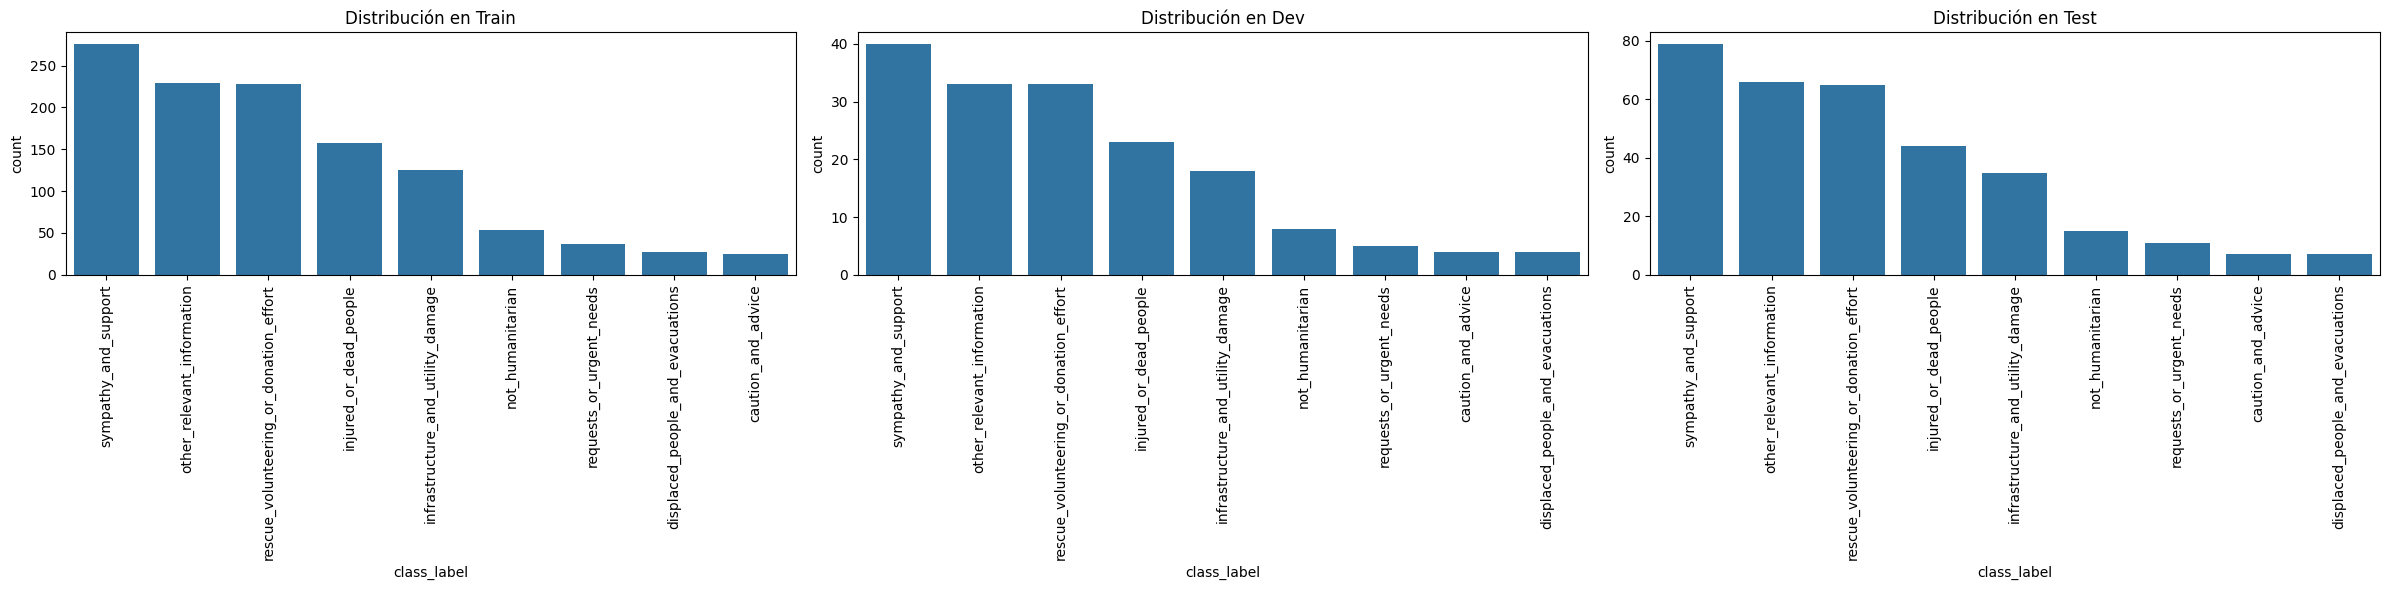

In [232]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# URLs directas a los archivos .tsv de Matthew 2016
url_train = "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_matthew_2016/hurricane_matthew_2016_train.tsv"
url_dev = "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_matthew_2016/hurricane_matthew_2016_dev.tsv"
url_test = "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_matthew_2016/hurricane_matthew_2016_test.tsv"

# Cargar en DataFrames
df_train = pd.read_csv(url_train, sep="\t")
df_dev = pd.read_csv(url_dev, sep="\t")
df_test = pd.read_csv(url_test, sep="\t")

# Ver primeras filas de cada conjunto
print("Train")
display(df_train.head())

print("Dev")
display(df_dev.head())

print("Test")
display(df_test.head())

print(f"Train shape: {df_train.shape}")
print(f"Dev shape: {df_dev.shape}")
print(f"Test shape: {df_test.shape}")

print("\nColumnas:")
print(df_train.columns)

# Crear una figura con 3 subgráficos (uno por conjunto)
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Gráfica para Train
sns.countplot(x='class_label', data=df_train, ax=axes[0],
              order=df_train['class_label'].value_counts().index)
axes[0].set_title('Distribución en Train')
axes[0].tick_params(axis='x', rotation=90)

# Gráfica para Dev
sns.countplot(x='class_label', data=df_dev, ax=axes[1],
              order=df_dev['class_label'].value_counts().index)
axes[1].set_title('Distribución en Dev')
axes[1].tick_params(axis='x', rotation=90)

# Gráfica para Test
sns.countplot(x='class_label', data=df_test, ax=axes[2],
              order=df_test['class_label'].value_counts().index)
axes[2].set_title('Distribución en Test')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

Huracán María 2015

Huracán María


,tweet_id,tweet_text,class_label,split
0,914134332226330625,San Juan: Trump lashes out with good reason. #...,other_relevant_information,train
1,910783670134476800,Hurricane Maria Live Updates: Catastrophic Flo...,caution_and_advice,train
2,912134938727780355,"Getting food to the island is, obviously, crit...",rescue_volunteering_or_donation_effort,train
3,910669838842056704,My heart breaks for the families in Puerto Ric...,sympathy_and_support,train
4,912287091026997248,"#B-FAST sending medical, reconstruction &amp; ...",rescue_volunteering_or_donation_effort,train


Shape: (7278, 4)
Columnas disponibles:
Index(['tweet_id', 'tweet_text', 'class_label', 'split'], dtype='object')


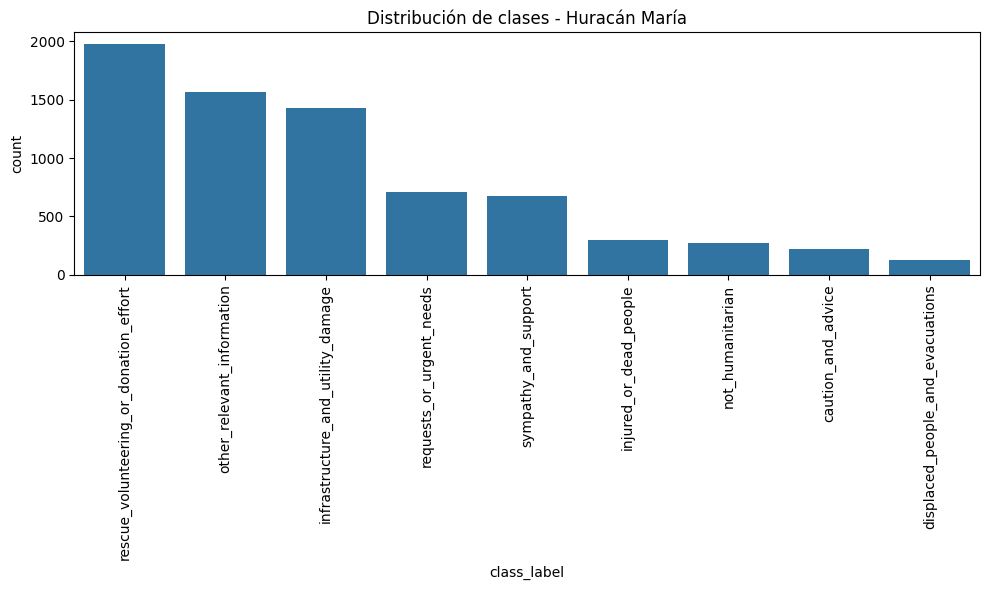

In [233]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# URL directa al CSV del Huracán María en GitHub
url_maria = "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_maria_tweets/HumAID_maria_tweets.csv"

# Cargar los datos
df_maria = pd.read_csv(url_maria)

# Visualizar primeras filas
print("Huracán María")
display(df_maria.head())

# Dimensiones
print(f"Shape: {df_maria.shape}")

# Revisar columnas
print("Columnas disponibles:")
print(df_maria.columns)

# Distribución de etiquetas
plt.figure(figsize=(10, 6))
sns.countplot(data=df_maria, x='class_label', order=df_maria['class_label'].value_counts().index)
plt.title("Distribución de clases - Huracán María")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Análisis exploratoior con toda la data concatenada

Datos concatenados

In [234]:
import pandas as pd

# Definir URLs por huracán
huracanes = {
    "dorian": {
        "train": "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_dorian_2019/hurricane_dorian_2019_train.tsv",
        "dev": "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_dorian_2019/hurricane_dorian_2019_dev.tsv",
        "test": "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_dorian_2019/hurricane_dorian_2019_test.tsv"
    },
    "florence": {
        "train": "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_florence_2018/hurricane_florence_2018_train.tsv",
        "dev": "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_florence_2018/hurricane_florence_2018_dev.tsv",
        "test": "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_florence_2018/hurricane_florence_2018_test.tsv"
    },
    "harvey": {
        "train": "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_harvey_2017/hurricane_harvey_2017_train.tsv",
        "dev": "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_harvey_2017/hurricane_harvey_2017_dev.tsv",
        "test": "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_harvey_2017/hurricane_harvey_2017_test.tsv"
    },
    "irma": {
        "train": "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_irma_2017/hurricane_irma_2017_train.tsv",
        "dev": "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_irma_2017/hurricane_irma_2017_dev.tsv",
        "test": "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_irma_2017/hurricane_irma_2017_test.tsv"
    },
    "matthew": {
        "train": "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_matthew_2016/hurricane_matthew_2016_train.tsv",
        "dev": "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_matthew_2016/hurricane_matthew_2016_dev.tsv",
        "test": "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_additional_hurricanes/hurricane_matthew_2016/hurricane_matthew_2016_test.tsv"
    },
    "maria": {
        "all": "https://raw.githubusercontent.com/marcoyuuu/PR-Disaster-Tweets/main/datasets/HumAID_maria_tweets/HumAID_maria_tweets.csv"
    }
}

# Leer y concatenar todos los datasets
dataframes = []
for huracan, urls in huracanes.items():
    for split, url in urls.items():
        if url.endswith(".tsv"):
            df = pd.read_csv(url, sep="\t")
        else:
            df = pd.read_csv(url)
        df["source"] = huracan
        df["split"] = split
        dataframes.append(df)

# Combinar en un único DataFrame
df_total = pd.concat(dataframes, ignore_index=True)

# Mostrar un resumen
print(df_total.shape)
df_total.head()

(41320, 5)


,tweet_id,tweet_text,class_label,source,split
0,1167883326872375298,Super important ahead of Hurricane Dorian - sh...,sympathy_and_support,dorian,train
1,1168209055086764044,As Category 5 Hurricane Dorian impacts the Bah...,other_relevant_information,dorian,train
2,1168320199407394816,"Bird, Lime, Spin and Jump sent their hurricane...",other_relevant_information,dorian,train
3,1167538295972216838,The District continues to monitor #HurricaneDo...,caution_and_advice,dorian,train
4,1167626335440855042,At this time all cilivan search and rescue tea...,rescue_volunteering_or_donation_effort,dorian,train


Guardar en un CSV

In [235]:
# Guardar el DataFrame combinado como CSV
output_path = "./results/humaid_dataset_completo.csv"
df_total.to_csv(output_path, index=False)
print(f"Archivo guardado exitosamente en: {output_path}")

Archivo guardado exitosamente en: ./results/humaid_dataset_completo.csv


Análisis exploratorio

Primeras filas del dataset:


,tweet_id,tweet_text,class_label,source,split
0,1167883326872375298,Super important ahead of Hurricane Dorian - sh...,sympathy_and_support,dorian,train
1,1168209055086764044,As Category 5 Hurricane Dorian impacts the Bah...,other_relevant_information,dorian,train
2,1168320199407394816,"Bird, Lime, Spin and Jump sent their hurricane...",other_relevant_information,dorian,train
3,1167538295972216838,The District continues to monitor #HurricaneDo...,caution_and_advice,dorian,train
4,1167626335440855042,At this time all cilivan search and rescue tea...,rescue_volunteering_or_donation_effort,dorian,train



Resumen general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41320 entries, 0 to 41319
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   tweet_id     41320 non-null  int64 
 1   tweet_text   41320 non-null  object
 2   class_label  41320 non-null  object
 3   source       41320 non-null  object
 4   split        41320 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.6+ MB

Número de valores nulos por columna:
tweet_id       0
tweet_text     0
class_label    0
source         0
split          0
dtype: int64

Estadísticas de longitud del texto:
count    41320.000000
mean       128.463480
std         56.712638
min         13.000000
25%         92.000000
50%        116.000000
75%        140.000000
max        884.000000
Name: text_length, dtype: float64


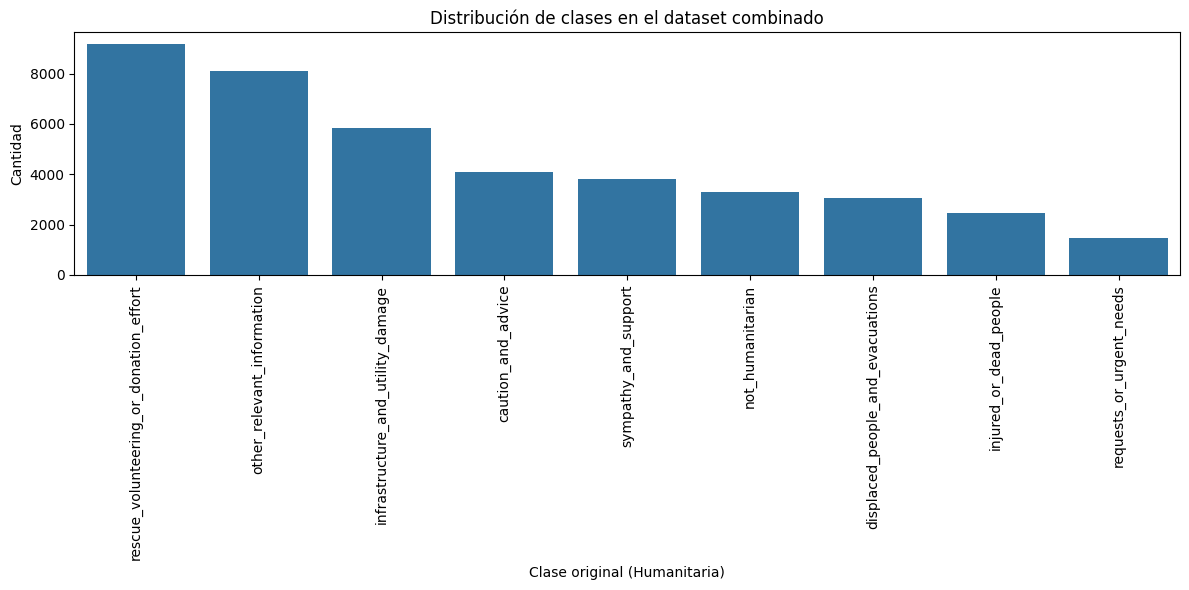

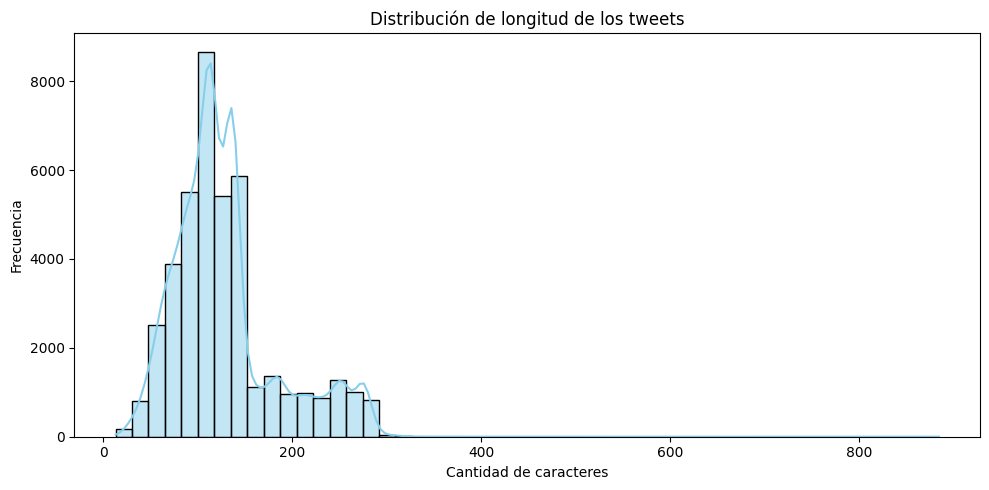

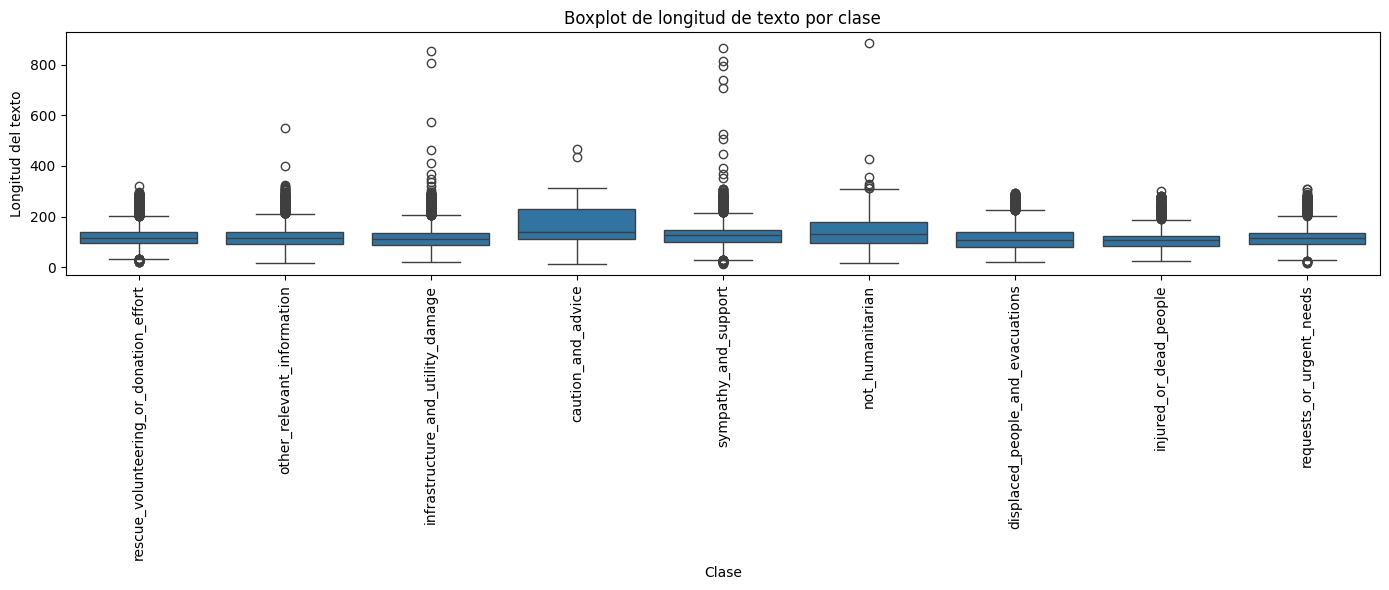

In [236]:
# ===============================
# ANÁLISIS EXPLORATORIO COMPLETO
# ===============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el archivo CSV combinado (asegúrate de haberlo subido o generado antes)
ruta_csv = './results/humaid_dataset_completo.csv'  # Ajusta si cambiaste el nombre o ubicación
df = pd.read_csv(ruta_csv)

# 1. Vista inicial del DataFrame
print("Primeras filas del dataset:")
display(df.head())

# 2. Información general
print("\nResumen general del DataFrame:")
df.info()

print("\nNúmero de valores nulos por columna:")
print(df.isnull().sum())

# 3. Estadísticas básicas de longitud del texto
df["text_length"] = df["tweet_text"].astype(str).apply(len)

print("\nEstadísticas de longitud del texto:")
print(df["text_length"].describe())

# 4. Distribución de clases
plt.figure(figsize=(12,6))
sns.countplot(x="class_label", data=df, order=df["class_label"].value_counts().index)
plt.title("Distribución de clases en el dataset combinado")
plt.xlabel("Clase original (Humanitaria)")
plt.ylabel("Cantidad")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 5. Histograma de longitudes de texto
plt.figure(figsize=(10,5))
sns.histplot(df["text_length"], bins=50, kde=True, color="skyblue")
plt.title("Distribución de longitud de los tweets")
plt.xlabel("Cantidad de caracteres")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# 6. Boxplot por clase
plt.figure(figsize=(14,6))
sns.boxplot(x="class_label", y="text_length", data=df, order=df["class_label"].value_counts().index)
plt.title("Boxplot de longitud de texto por clase")
plt.xlabel("Clase")
plt.ylabel("Longitud del texto")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Reclasificación del dataset

Clases originales:
class_label
rescue_volunteering_or_donation_effort    9181
other_relevant_information                8101
infrastructure_and_utility_damage         5838
caution_and_advice                        4089
sympathy_and_support                      3824
not_humanitarian                          3305
displaced_people_and_evacuations          3051
injured_or_dead_people                    2475
requests_or_urgent_needs                  1456
Name: count, dtype: int64

Distribución de clases reclasificadas:
class_reclasificada
informativo       26090
neutral           11925
no_informativo     3305
Name: count, dtype: int64


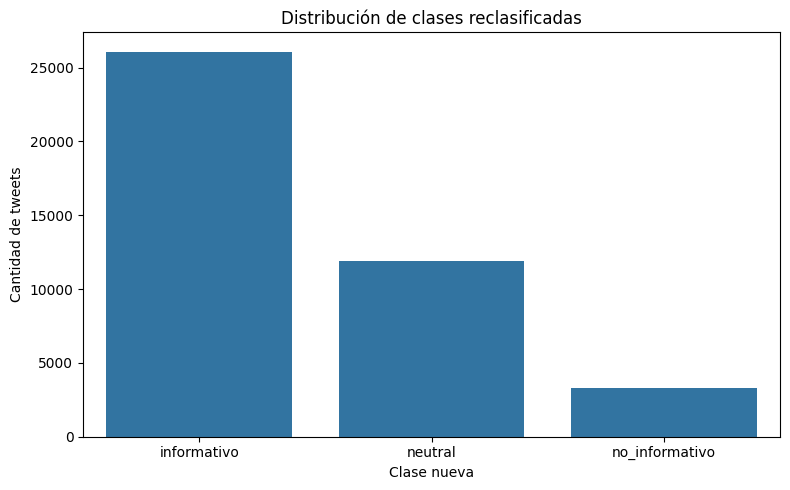


✅ Archivo guardado como 'humaid_dataset_reclasificado.csv'


In [237]:
# ==============================
# RECLASIFICACIÓN DE CATEGORÍAS
# ==============================

# Cargar el dataset completo si aún no lo has hecho
import pandas as pd

ruta_csv = "./results/humaid_dataset_completo.csv"
df = pd.read_csv(ruta_csv)

# Revisar clases originales
print("Clases originales:")
print(df["class_label"].value_counts())

# Diccionario de reclasificación
mapa_reclasificacion = {
    "rescue_volunteering_or_donation_effort": "informativo",
    "infrastructure_and_utility_damage": "informativo",
    "caution_and_advice": "informativo",
    "injured_or_dead_people": "informativo",
    "requests_or_urgent_needs": "informativo",
    "displaced_people_and_evacuations": "informativo",

    "not_humanitarian": "no_informativo",

    "sympathy_and_support": "neutral",
    "other_relevant_information": "neutral"
}

# Aplicar nueva columna con la clase reclasificada
df["class_reclasificada"] = df["class_label"].map(mapa_reclasificacion)

# Verificar resultados
print("\nDistribución de clases reclasificadas:")
print(df["class_reclasificada"].value_counts())

# Visualización de la nueva distribución
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x="class_reclasificada", data=df, order=["informativo", "neutral", "no_informativo"])
plt.title("Distribución de clases reclasificadas")
plt.xlabel("Clase nueva")
plt.ylabel("Cantidad de tweets")
plt.tight_layout()
plt.show()

# Guardar el nuevo dataset reclasificado
df.to_csv("./results/humaid_dataset_reclasificado.csv", index=False)
print("\n✅ Archivo guardado como 'humaid_dataset_reclasificado.csv'")

## Preprocesamiento de la data

In [238]:
# ===============================
# PREPROCESAMIENTO DEL TEXTO
# ===============================

import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Descargar recursos de NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Leer el dataset reclasificado
ruta_csv = "./results/humaid_dataset_reclasificado.csv"
df = pd.read_csv(ruta_csv)

# Inicializar stopwords y lematizador
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Función de limpieza
def clean_tweet(text):
    if pd.isnull(text):
        return ""

    # 1. Minúsculas
    text = text.lower()

    # 2. Quitar caracteres HTML
    text = re.sub(r"&\w+;", " ", text)

    # 3. Quitar URLs
    text = re.sub(r"http\S+|www.\S+", "", text)

    # 4. Quitar menciones
    text = re.sub(r"@\w+", "", text)

    # 5. Quitar el # pero conservar el texto
    text = re.sub(r"#(\w+)", r"\1", text)

    # 6. Quitar puntuación
    text = text.translate(str.maketrans("", "", string.punctuation))

    # 7. Quitar números
    text = re.sub(r"\d+", "", text)

    # 8. Tokenizar, remover stopwords y lematizar
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

# Aplicar a la columna 'tweet_text'
df['clean_text'] = df['tweet_text'].apply(clean_tweet)

# Ver ejemplo de antes y después
df[['tweet_text', 'clean_text']].sample(5)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Marco\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Marco\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Marco\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,tweet_text,clean_text
4887,• Flash Sale • Due to Hurricane Dorian causing...,• flash sale • due hurricane dorian causing fa...
20454,Hurricane Harvey has displaced an unimaginable...,hurricane harvey displaced unimaginable number...
8516,RT @AngelaAn10TV: Phone lines are active now! ...,rt phone line active tv hurricane florence relief
32907,Hurricane Matthew has devastated Haiti. Suppor...,hurricane matthew devastated haiti support joi...
29047,Floridians assess Irmas wreckage as death toll...,floridian assess irmas wreckage death toll mou...


Guardar este data set procesado

In [239]:
# ===============================
# GUARDAR EL DATASET PREPROCESADO
# ===============================

# Verificar algunas filas antes de guardar
print(df[['tweet_text', 'clean_text']].head())

# Guardar el DataFrame con la columna clean_text
ruta_salida = "./results/humaid_dataset_preprocesado.csv"
df.to_csv(ruta_salida, index=False)

print(f"Archivo guardado exitosamente en: {ruta_salida}")

                                          tweet_text  \
0  Super important ahead of Hurricane Dorian - sh...   
1  As Category 5 Hurricane Dorian impacts the Bah...   
2  Bird, Lime, Spin and Jump sent their hurricane...   
3  The District continues to monitor #HurricaneDo...   
4  At this time all cilivan search and rescue tea...   

                                          clean_text  
0  super important ahead hurricane dorian shelter...  
1  category hurricane dorian impact bahamas suppl...  
2  bird lime spin jump sent hurricane preparednes...  
3  district continues monitor hurricanedorian pot...  
4  time cilivan search rescue team standby waitin...  
Archivo guardado exitosamente en: ./results/humaid_dataset_preprocesado.csv


In [240]:
print(df.columns)

Index(['tweet_id', 'tweet_text', 'class_label', 'source', 'split',
       'class_reclasificada', 'clean_text'],
      dtype='object')


In [241]:
# Crear columna de longitud en número de palabras
df['tweet_length'] = df['clean_text'].apply(lambda x: len(str(x).split()))

C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\229853455.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class_reclasificada', y='tweet_length', data=df, palette='Set2')


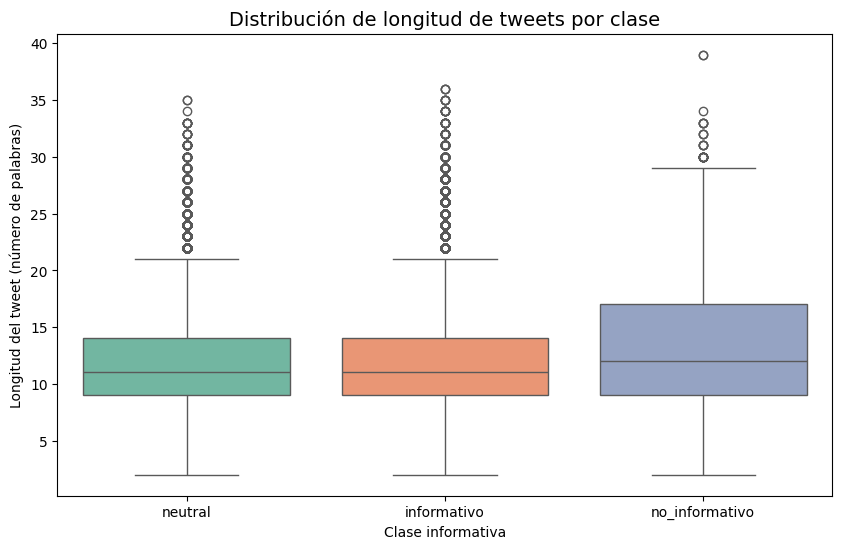

In [242]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot: longitud de tweets por clase reclasificada
plt.figure(figsize=(10, 6))
sns.boxplot(x='class_reclasificada', y='tweet_length', data=df, palette='Set2')
plt.title("Distribución de longitud de tweets por clase", fontsize=14)
plt.xlabel("Clase informativa")
plt.ylabel("Longitud del tweet (número de palabras)")
plt.show()

In [243]:
df['class_reclasificada'].value_counts()

class_reclasificada
informativo       26090
neutral           11925
no_informativo     3305
Name: count, dtype: int64

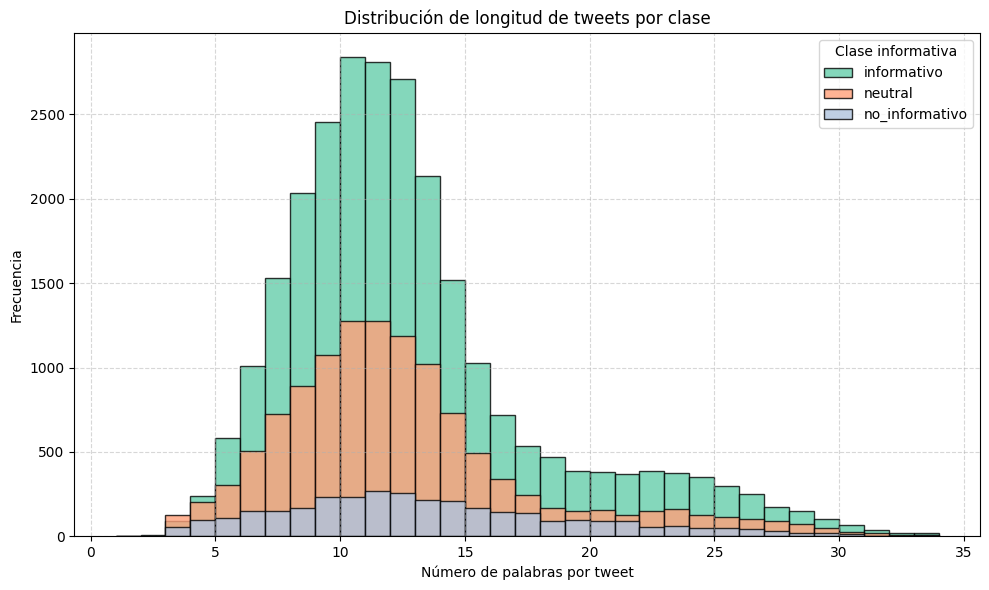

In [244]:
import matplotlib.pyplot as plt

# Definir las clases según la columna class_reclasificada en español
clases = ['informativo', 'neutral', 'no_informativo']

# Colores personalizados por clase
colores = ['mediumaquamarine', 'lightsalmon', 'lightsteelblue']

# Crear la figura
plt.figure(figsize=(10, 6))
bins = range(1, 35)

# Dibujar histograma para cada clase
for clase, color in zip(clases, colores):
    subset = df[df['class_reclasificada'] == clase]
    if not subset.empty:
        plt.hist(subset['tweet_length'], bins=bins, alpha=0.8, label=clase,
                 edgecolor='black', color=color)

# Personalización del gráfico
plt.title("Distribución de longitud de tweets por clase")
plt.xlabel("Número de palabras por tweet")
plt.ylabel("Frecuencia")
plt.legend(title="Clase informativa")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### CountVecorizer with BoW

In [245]:
from sklearn.feature_extraction.text import CountVectorizer

# =========================
# 1. Vectorización con BoW
# =========================

vectorizer_bow = CountVectorizer(
    lowercase=True,
    stop_words='english',
    max_df=0.95,
    min_df=5,
    max_features=10000  # Ajustado para mayor volumen de datos
)

# Aplicar al texto limpio
X_bow = vectorizer_bow.fit_transform(df['clean_text'])

# Inspección rápida
print("BoW - Forma de la matriz:", X_bow.shape)
print("BoW - Primeras 10 palabras:", vectorizer_bow.get_feature_names_out()[:10])

BoW - Forma de la matriz: (41320, 6535)
BoW - Primeras 10 palabras: ['aa' 'ab' 'abaco' 'abacoisland' 'abacoislands' 'abacos' 'abandon'
 'abandoned' 'abbott' 'abc']


CountVectorizer with TfidVectorizer

In [246]:
from sklearn.feature_extraction.text import TfidfVectorizer

# =============================
# 2. Vectorización con TF-IDF
# =============================

# Asegurar que los textos sean válidos y que la clase esté definida
df_valid = df[df['clean_text'].notnull() & df['class_reclasificada'].notnull()].copy()

vectorizer_tfidf = TfidfVectorizer(
    stop_words='english',
    max_df=0.95,
    min_df=5,
    max_features=10000,  # Mismo número de características que BoW
    ngram_range=(1,1)
)

# Aplicar TF-IDF
X_tfidf = vectorizer_tfidf.fit_transform(df_valid['clean_text'])

# Inspección rápida
print("TF-IDF - Forma de la matriz:", X_tfidf.shape)
print("TF-IDF - Primeras 10 palabras:", vectorizer_tfidf.get_feature_names_out()[:10])

TF-IDF - Forma de la matriz: (41320, 6535)
TF-IDF - Primeras 10 palabras: ['aa' 'ab' 'abaco' 'abacoisland' 'abacoislands' 'abacos' 'abandon'
 'abandoned' 'abbott' 'abc']


In [249]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Vectorizador BoW (Bolsa de Palabras)
vectorizer = CountVectorizer(
    lowercase=True,
    stop_words='english',
    max_df=0.95,
    min_df=5,
    max_features=10000
)

# Crear df_train_full a partir de df_total si no está definido
df_train_full = df_total[df_total['split'] == 'train']

# Asegurarse de que la columna 'clean_text' exista
if 'clean_text' not in df_train_full.columns:
    import re
    import string
    from nltk.corpus import stopwords
    from nltk.stem import WordNetLemmatizer
    nltk.download('stopwords')
    nltk.download('wordnet')
    nltk.download('omw-1.4')

    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    def clean_tweet(text):
        if pd.isnull(text):
            return ""
        text = text.lower()
        text = re.sub(r"&\w+;", " ", text)
        text = re.sub(r"http\S+|www.\S+", "", text)
        text = re.sub(r"@\w+", "", text)
        text = re.sub(r"#(\w+)", r"\1", text)
        text = text.translate(str.maketrans("", "", string.punctuation))
        text = re.sub(r"\d+", "", text)
        words = text.split()
        words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
        return " ".join(words)

    df_train_full['clean_text'] = df_train_full['tweet_text'].apply(clean_tweet)
    df_test['clean_text'] = df_test['tweet_text'].apply(clean_tweet)

# Ajustar BoW solo sobre entrenamiento completo
X_train_bow = vectorizer.fit_transform(df_train_full['clean_text'])
X_test_bow = vectorizer.transform(df_test['clean_text'])

print("BoW - Shape de entrenamiento:", X_train_bow.shape)
print("BoW - Shape de prueba:", X_test_bow.shape)

# Vectorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.95,
    min_df=5,
    max_features=10000,
    ngram_range=(1,1)  # unigramas
)

# Ajustar TF-IDF solo sobre entrenamiento completo
X_train_tfidf = tfidf_vectorizer.fit_transform(df_train_full['clean_text'])
X_test_tfidf = tfidf_vectorizer.transform(df_test['clean_text'])

print("TF-IDF - Shape de entrenamiento:", X_train_tfidf.shape)
print("TF-IDF - Shape de prueba:", X_test_tfidf.shape)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Marco\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Marco\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Marco\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
C:\Users\Marco\AppData\Local\Temp\ipykernel_1864\3549971161.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_full['clean_text'] = df_train_full['tweet_text'].apply(clean_tweet)


BoW - Shape de entrenamiento: (23827, 4795)
BoW - Shape de prueba: (329, 4795)
TF-IDF - Shape de entrenamiento: (23827, 4795)
TF-IDF - Shape de prueba: (329, 4795)
TF-IDF - Shape de entrenamiento: (23827, 4795)
TF-IDF - Shape de prueba: (329, 4795)


## Training Set y Test Set

In [250]:
from sklearn.model_selection import train_test_split

# Asumiendo que ya tienes la columna 'split' del HumAID original
df_train = df[df['split'] == 'train'].copy()
df_dev = df[df['split'] == 'dev'].copy()
df_test = df[df['split'] == 'test'].copy()

# También puedes combinar train y dev si así lo deseas:
df_train_full = pd.concat([df_train, df_dev], axis=0)

print("Tamaño del conjunto de entrenamiento (train + dev):", df_train_full.shape)
print("Tamaño del conjunto de prueba:", df_test.shape)

# Crear los vectores de entrada y las etiquetas
X_train_bow = vectorizer.transform(df_train_full['clean_text'])
X_test_bow = vectorizer.transform(df_test['clean_text'])

X_train_tfidf = tfidf_vectorizer.transform(df_train_full['clean_text'])
X_test_tfidf = tfidf_vectorizer.transform(df_test['clean_text'])

# Etiquetas (codificadas manualmente)
y_train = df_train_full['class_reclasificada']
y_test = df_test['class_reclasificada']

# Confirmar
print("BoW - Shape de entrenamiento:", X_train_bow.shape)
print("BoW - Shape de prueba:", X_test_bow.shape)
print("TF-IDF - Shape de entrenamiento:", X_train_tfidf.shape)
print("TF-IDF - Shape de prueba:", X_test_tfidf.shape)

Tamaño del conjunto de entrenamiento (train + dev): (27297, 8)
Tamaño del conjunto de prueba: (6745, 8)
BoW - Shape de entrenamiento: (27297, 4795)
BoW - Shape de prueba: (6745, 4795)
TF-IDF - Shape de entrenamiento: (27297, 4795)
TF-IDF - Shape de prueba: (6745, 4795)


## Naive Bayes with BoW (unigrama)

📊 Reporte de clasificación - Naive Bayes (BoW unigram):
                precision    recall  f1-score   support

   informativo       0.80      0.86      0.83      4223
       neutral       0.64      0.52      0.58      1921
no_informativo       0.47      0.52      0.50       601

      accuracy                           0.73      6745
     macro avg       0.64      0.63      0.63      6745
  weighted avg       0.73      0.73      0.73      6745



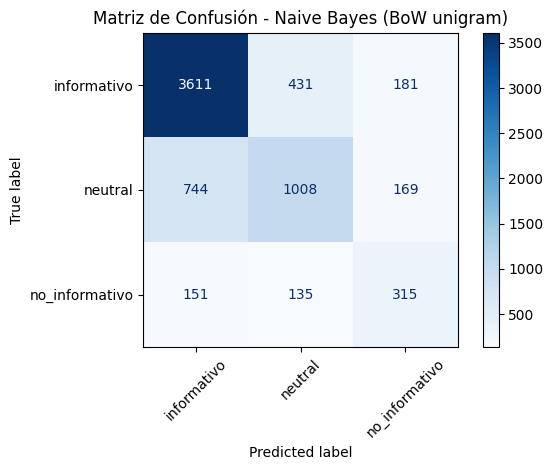

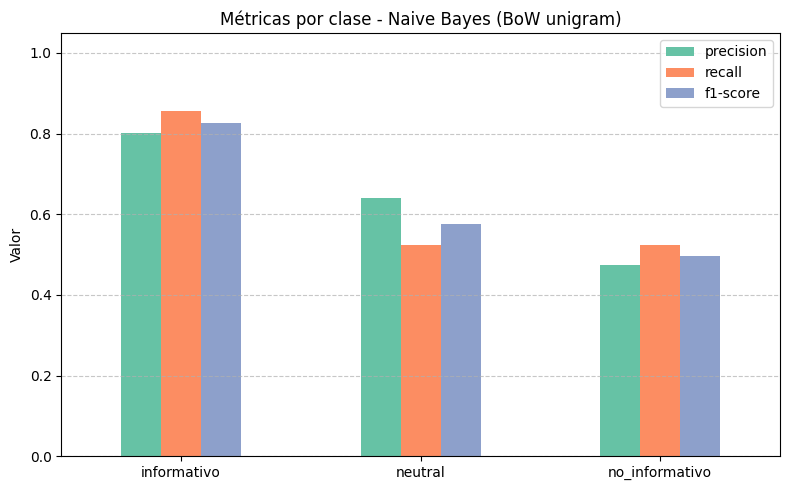

In [251]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Etiquetas verdaderas
y_train = df_train_full['class_reclasificada']
y_test = df_test['class_reclasificada']

# Entrenamiento del modelo
nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)

# Predicciones
y_pred = nb_model.predict(X_test_bow)

# Reporte de clasificación
print("📊 Reporte de clasificación - Naive Bayes (BoW unigram):")
print(classification_report(y_test, y_pred, digits=2))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=nb_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nb_model.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión - Naive Bayes (BoW unigram)")
plt.tight_layout()
plt.show()

# Visualización por clase de Precision, Recall y F1
report_dict = classification_report(y_test, y_pred, output_dict=True)
df_metrics = pd.DataFrame(report_dict).transpose().iloc[:3][['precision', 'recall', 'f1-score']]

# Gráfico
df_metrics.plot(kind='bar', figsize=(8,5), color=['#66c2a5','#fc8d62','#8da0cb'])
plt.title("Métricas por clase - Naive Bayes (BoW unigram)")
plt.ylabel("Valor")
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## SVM con TF-IDF

📊 Reporte de clasificación - SVM (TF-IDF):


,precision,recall,f1-score,support
informativo,0.821754,0.876628,0.848304,4223.000000
neutral,0.655154,0.622072,0.638184,1921.000000
no_informativo,0.584135,0.404326,0.477876,601.000000
accuracy,0.762046,0.762046,0.762046,0.762046
macro avg,0.687014,0.634342,0.654788,6745.000000
weighted avg,0.753133,0.762046,0.755455,6745.000000


c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128311 (\N{LARGE BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


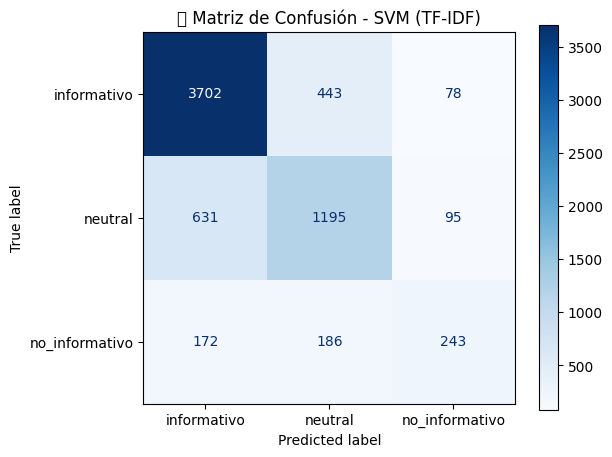

c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


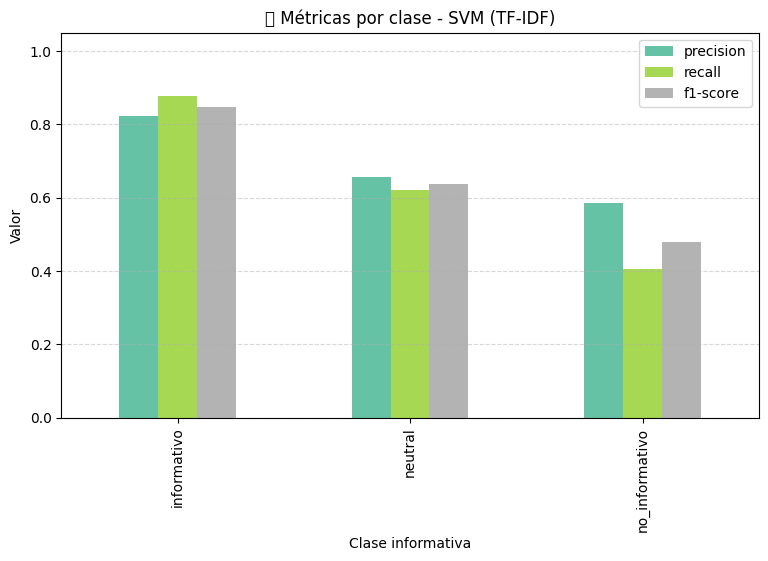

In [252]:
# === SVM con TF-IDF ===
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Entrenar el modelo
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

# Predicción
y_pred_svm = svm_model.predict(X_test_tfidf)

# Reporte de clasificación
report_svm = classification_report(y_test, y_pred_svm, output_dict=True)
print("📊 Reporte de clasificación - SVM (TF-IDF):")
display(pd.DataFrame(report_svm).transpose())

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_svm, labels=svm_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues")
plt.title("🔷 Matriz de Confusión - SVM (TF-IDF)")
plt.show()

# Métricas por clase
df_metrics = pd.DataFrame(report_svm).T.loc[['informativo', 'neutral', 'no_informativo'], ['precision', 'recall', 'f1-score']]
df_metrics.plot(kind='bar', figsize=(9, 5), colormap='Set2')
plt.title("📈 Métricas por clase - SVM (TF-IDF)")
plt.ylabel("Valor")
plt.xlabel("Clase informativa")
plt.ylim(0, 1.05)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## Regresión Logística con BoW (unigrama)

📊 Reporte de clasificación - Regresión Logística (BoW unigrama):
                precision    recall  f1-score   support

   informativo       0.83      0.88      0.85      4223
       neutral       0.66      0.65      0.65      1921
no_informativo       0.62      0.40      0.48       601

      accuracy                           0.77      6745
     macro avg       0.70      0.64      0.66      6745
  weighted avg       0.76      0.77      0.76      6745



c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


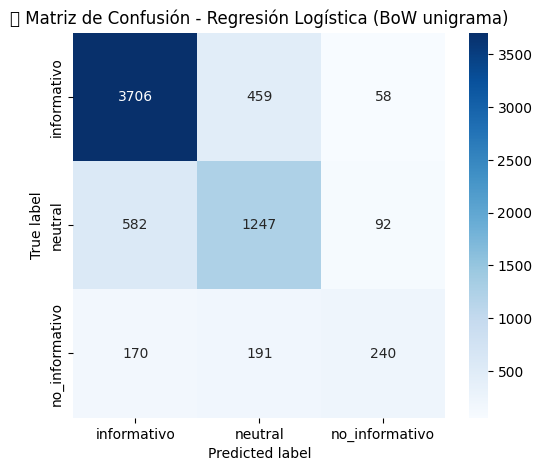

c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


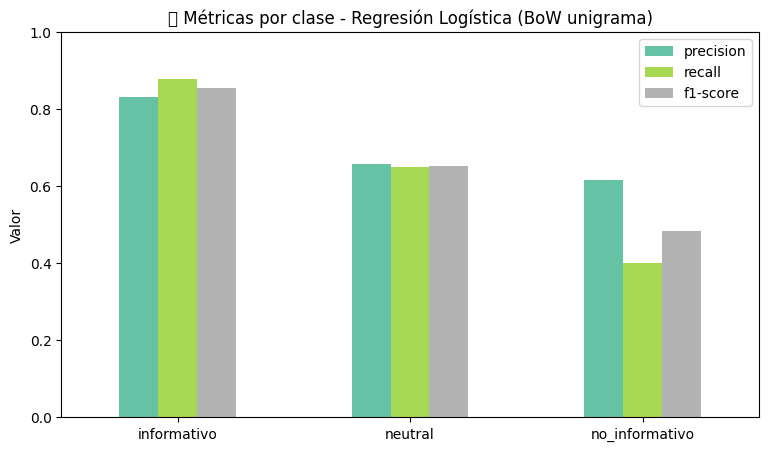

In [253]:
# ============================
# REGRESIÓN LOGÍSTICA con BoW
# ============================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Entrenar el modelo
logreg_model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
logreg_model.fit(X_train_bow, y_train)

# Predicciones
y_pred_logreg = logreg_model.predict(X_test_bow)

# Reporte de clasificación
print("📊 Reporte de clasificación - Regresión Logística (BoW unigrama):")
print(classification_report(y_test, y_pred_logreg))

# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred_logreg, labels=logreg_model.classes_)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=logreg_model.classes_, yticklabels=logreg_model.classes_)
plt.title("📉 Matriz de Confusión - Regresión Logística (BoW unigrama)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# Métricas por clase (precisión, recall, f1-score)
report_dict = classification_report(y_test, y_pred_logreg, output_dict=True)
df_metrics = pd.DataFrame(report_dict).transpose().loc[['informativo', 'neutral', 'no_informativo']]
df_metrics = df_metrics[['precision', 'recall', 'f1-score']]

# Gráfico de métricas por clase
df_metrics.plot(kind='bar', figsize=(9, 5), colormap='Set2')
plt.title("📈 Métricas por clase - Regresión Logística (BoW unigrama)")
plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.show()

## Red Neuronal con Regularización L2, Dropout y Class_weight

Pesos por clase: {0: np.float64(0.5321363822445757), 1: np.float64(1.1719474497681608), 2: np.float64(3.738290879211175)}


c:\Users\Marco\Uni\ML\Proyecto\PR-Disaster-Tweets\.venv311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5036 - loss: 1.1859 - val_accuracy: 0.7531 - val_loss: 0.8252
Epoch 2/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7274 - loss: 0.8989 - val_accuracy: 0.7553 - val_loss: 0.8371
Epoch 3/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7509 - loss: 0.8694 - val_accuracy: 0.7590 - val_loss: 0.8548
Epoch 4/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7733 - loss: 0.8283 - val_accuracy: 0.7641 - val_loss: 0.8644
Epoch 5/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7906 - loss: 0.8088 - val_accuracy: 0.7692 - val_loss: 0.8800
Epoch 6/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8105 - loss: 0.7787 - val_accuracy: 0.7634 - val_loss: 0.9156
Epoch 7/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8328 - loss: 0.7413 - val_accuracy: 0.7564 - val_loss: 0.9434
Epoch 8/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8409 - loss: 0.7149 - val_accuracy: 0.

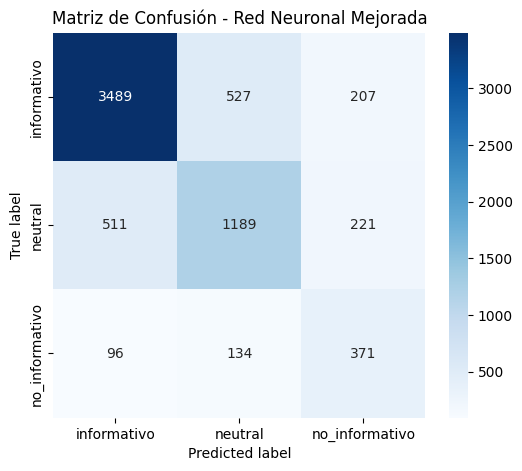

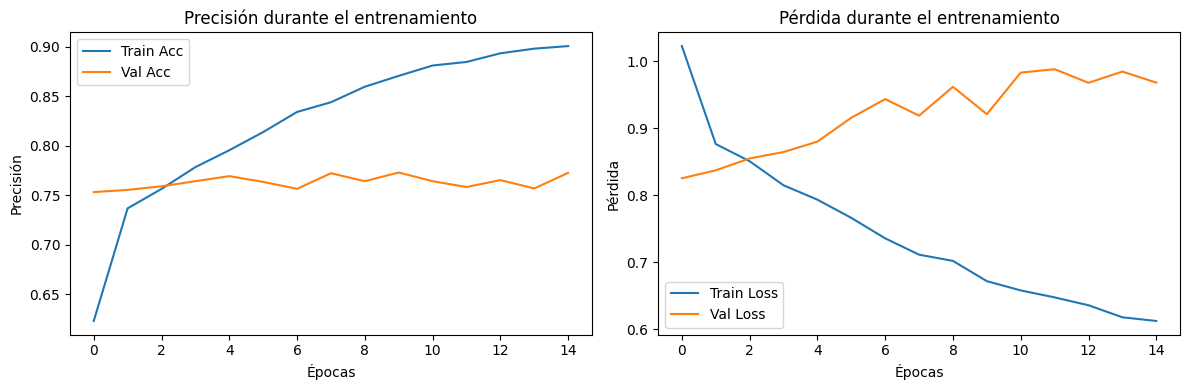

In [254]:
# Librerías necesarias
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurar reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

# Codificación de etiquetas a números
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# One-hot encoding para Keras
y_train_cat = to_categorical(y_train_enc, num_classes=3)
y_test_cat = to_categorical(y_test_enc, num_classes=3)

# Cálculo de pesos por clase
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_enc),
    y=y_train_enc
)
class_weights_dict = dict(enumerate(class_weights))
print("Pesos por clase:", class_weights_dict)

# Definir modelo de red neuronal con regularización L2 y Dropout
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_tfidf.shape[1],), kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(3, activation='softmax')  # 3 clases
])

# Compilación
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entrenamiento
history = model.fit(
    X_train_tfidf,
    y_train_cat,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weights_dict,
    verbose=1
)

# Evaluación en test
test_loss, test_acc = model.evaluate(X_test_tfidf, y_test_cat, verbose=0)
print(f"\nAccuracy en test: {test_acc:.4f}")

# Predicciones
y_pred_probs = model.predict(X_test_tfidf)
y_pred = np.argmax(y_pred_probs, axis=1)

# Reporte de clasificación
print("\nReporte de clasificación - Red Neuronal Mejorada:\n")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

# Matriz de confusión
cm = confusion_matrix(y_test_enc, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Matriz de Confusión - Red Neuronal Mejorada")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# Gráfica de métricas de entrenamiento
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Precisión durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.tight_layout()
plt.show()

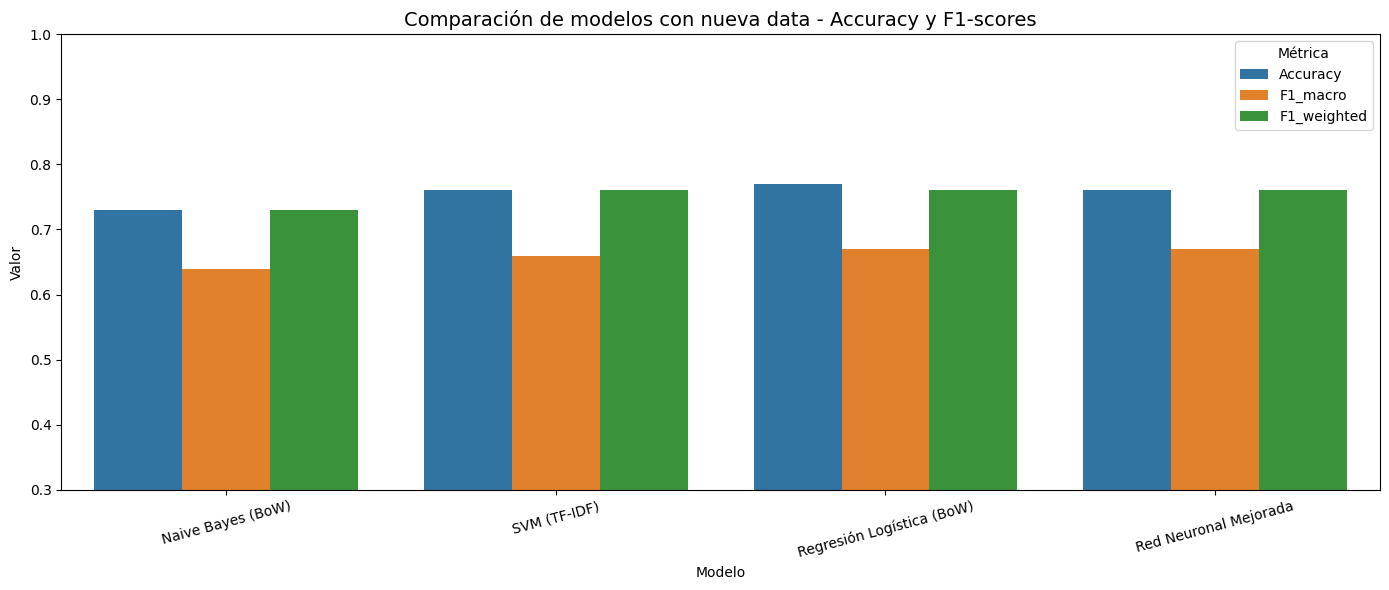

In [255]:
import matplotlib.pyplot as plt
import pandas as pd

# Métricas de desempeño para cada modelo entrenado con la nueva data
resultados = {
    'Modelo': [
        'Naive Bayes (BoW)',
        'SVM (TF-IDF)',
        'Regresión Logística (BoW)',
        'Red Neuronal Mejorada'
    ],
    'Accuracy': [0.73, 0.76, 0.77, 0.76],
    'F1_macro': [0.64, 0.66, 0.67, 0.67],
    'F1_weighted': [0.73, 0.76, 0.76, 0.76]
}

# Crear DataFrame
df_resultados = pd.DataFrame(resultados)

# Transformar a formato largo para graficar con Seaborn
df_long = df_resultados.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

# Gráfico de barras comparativo
import seaborn as sns
plt.figure(figsize=(14, 6))
sns.barplot(data=df_long, x='Modelo', y='Valor', hue='Métrica')
plt.title('Comparación de modelos con nueva data - Accuracy y F1-scores', fontsize=14)
plt.ylim(0.3, 1.0)
plt.xticks(rotation=15)
plt.legend(title='Métrica')
plt.tight_layout()
plt.show()
